
revision version log:
v1- created 1/14/26
-importing processing code from revision cloud autoencoder iteration. importing modeling code from local_Fig_decode_setup_v18.ipynb
v5- created pinning of memory, added null permutation of labels for null boundary creation
v6- creation of random subsample

original changelog:
v9- 9/26/24'; added updated time-series importing logic to ensure congruence across different csripts.
10/10/24; added Late IA vs Early RS comparison for decoding (+ weight testing)
using new packaging logic develoepd ~ v7
v11- 10/29/24
-adding cross-stage out of distribution testing for decoding (e.g. train on IA Error vs RS Erorr, test on IA correct vs RS Correct)
v12- 11/11/24 running on 3,15,250, 0.01 abs spike detection params
v13- 11/14/24- running on gauss_smooth + 80% cutoff + temporal dedup, also deleting PCA save step as you are regenerating PC projection with new boostrap pulls in the plotting version of this
v15- 12/4/24- testing # of Early RS COrrect trials occuring b4 and after the Early RS Error trials.
v18- drop time-dependent activity decoding, introduced stratified kfold split



## Setup


In [44]:
%load_ext autoreload
%autoreload 2
from __future__ import annotations
import os
import sys
from pathlib import Path
from typing import List, Any, Dict
import numpy as np
import pandas as pd
import shutil
import time
import json
import itertools
from datetime import datetime
from functools import partial
from sklearn import svm, metrics, model_selection

from joblib import Parallel, delayed  # from functools import partial #for specific type of parallel deployment
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='seaborn')

#load preprocess specific functions
import notebook_setup
info = notebook_setup.setup()
# from run_manifest import create_run_manifest, update_run_database
from config_preprocessing import load_config
from analysis_config_loader import load_analysis_config  # new import, personal config 

preprocess_func_folder = Path(info["repo_root"]) / "preprocess_functions"
sys.path.append(str(preprocess_func_folder)) #add preprocess_functions folder to path to load modules
# from detect_cell_enrichment import get_cell_stage_enrichment, get_cell_ensemble_info_per_subject
from preprocessing_utils import dataset_obj_to_df, transform_all_datasets, extract_trial_windows, create_subject_trial_tseries_df
from preprocess_functions.shuffle_methods import prepare_shuffle_data, create_shuffled_df_preconverted, log_shuffle_run, get_latest_shuffle_folder, load_latest_shuffle_run
from preprocess_data import hyper_param_dict, bin_rotate_timeseries, get_numeric_cols_timeseries, get_unit_mean_timeseries_by_phase, drop_end_bins_of_trials, drop_start_bins_of_trials, add_enriched_in_curr_phase_col, get_subject_stage_info_df
from helper_functions import *
from phase_enrich_timeseries_decode import plot_unit_enrich_by_phase_summary

# set up plotting code
import matplotlib as matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sns_plotting_config import * #import dicts containing default plot params
try:
    pd.get_option('mode.use_inf_as_null')
except pd._config.config.OptionError:
    pd._config.config.register_option('mode.use_inf_as_null', False, "Deprecated - for seaborn 0.12.x compatibility")
    
# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")
# set up locations for input/output 
root_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\code')
os.chdir(root_dir)

#import local yaml for env preset variables
config_path = Path(r"analysis_config.yaml")  # adjust as needed
analysis_config = load_analysis_config(config_path)
stage_names = analysis_config.task_phase_names
print(analysis_config)

# Load general file configuration
config = load_config('config.yaml')
data_type = config['data']['data_type_used']
preprocessing = config['preprocessing']
shuffle_cfg = config['shuffles']
print(config)

# Create unique run ID
RUN_ID = datetime.now().strftime('%Y%m%d_%H%M')
START_TIME = time.time()

# Create output directory with run ID
results_dir = config['data']['results_dir']
run_output_dir = results_dir / 'shuffles' / f"shuffle_run_{RUN_ID}"
run_output_dir.mkdir(parents=True, exist_ok=True)

#set data location
data_dir = config['data']['data_dir']
source_dataset_location= config['data']['source_dataset_location']

#hardcoded/old links for checking
hardcode_results_dir = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results")
hardcode_data_dir = Path(r'c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data')
hardcode_source_dataset_location = Path(r"C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\dataset_objects_24-Nov-2024_hour_19") #source dataset location has files created 10-26-2024

#print config paths for verification
print(f"Run ID: {RUN_ID}, Started: {datetime.now()}")
print(f"\nFolders used in run ID: {RUN_ID}")
print(f"Results dir: {results_dir}")
print(f"Data dir: {data_dir}")
print(f"Source dataset location: {source_dataset_location}")
# Copy config to output directory for reference
shutil.copy('config.yaml', run_output_dir / 'config_used.yaml')



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle
AnalysisConfig(trial_section_names=['pre_outcome', 'post_outcome', 'ITI'], phase_division_types=['simple', 'complex'], task_phase_names=['Early_IA_Error', 'Early_IA_Correct', 'Late_IA', 'Early_RS_Error', 'Early_RS_Correct', 'Late_RS'], simple_phase_names=['IA_Error', 'IA_Correct', 'RS_Error', 'RS_Correct'], feature_type_names=['correct_error', 'IA_RS', 'task_phase'], phase_is_solo_vector=True, shuffle_to_use='circle', num_shuffles=1000, early_division_criteria_types=['count', 'first_2'], early_criteria_type='count', early_criteria_value=5, trial_section_divisions=[], corr_vector_is_triangular=True, seconds_before_post_to_keep=5, time_series_bin_size=0.25, corr_time_series_bin_size=0.5, percentile=95, threshold_with_shuffle=True, min_baseline_len=12000, final_

WindowsPath('C:/Users/13car/Dropbox/local_github_repos_personal/dlx56_mPFC_1p_SohalLab/results/shuffles/shuffle_run_20260820_1457/config_used.yaml')

In [45]:
##IMPORT TIME_SERIES
#set unit name and type of data
units = 'cells'
#declare loc/names of files to read
output_folder = os.getcwd() +"/output/"
use_new_dataset = True
use_dff = False
data_type = 'post_outcome_activity'
if use_new_dataset:
    #latest matlab run: 
    if use_dff:
        data_type = 'post_dff'
        new_trial_df_filename = data_dir /  r"matlab_import_1000_shuff_minmax_normed_trial_tseries_26-Feb-2026\dff_matlab-made_trial_timeseries_normalized_2026-02-26 21.parquet"
    else:
        new_trial_df_filename = data_dir /  r"matlab-made_trial_timeseries_normalized_2026-01-31 17.parquet" # new matlab made 10k shuffle file     
    #if data is from new_dataset
    subject_col = 'subject_name'
    unit_ID_col = 'neuron_ID'
else: 
    new_trial_df_filename = f"Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet"
    #if data is from old dataset:
    subject_col = 'name'
    unit_ID_col = 'unique_ID'
# new_trial_df_filename = Path(r"python-made_trial_timeseries_raster_2025-12-21 12.parquet")

trial_df_filename = data_dir /  new_trial_df_filename
print(f"loading_dataset {new_trial_df_filename} \n from {trial_df_filename}")
trial_tseries_df_norm = pd.read_parquet(trial_df_filename)
trial_tseries_df_norm.tail()
#col names for analysis
stage_col = 'task_phase_vec'
# get stage names from data
stage_names = sorted(trial_tseries_df_norm[stage_col].unique())#hardcode the stage_names (to not rely on the order of the 'unique() vector of the df
numeric_col = get_numeric_cols_timeseries(trial_tseries_df_norm, " to ")
unit_mean_tseries =  get_unit_mean_timeseries_by_phase(trial_tseries_df_norm,['trial_num'], [subject_col, unit_ID_col,'geno_day', stage_col], numeric_col) 
# note informative stats for refernce later if necessary
subject_stage_info_df = get_subject_stage_info_df(trial_tseries_df_norm, cell_id_name_col = unit_ID_col, subj_name_col = subject_col)#.rename({unit_ID_col: "unique_ID"},axis = 1) # get subj level dfs
n_total_units = unit_mean_tseries.groupby(by = 'geno_day')[unit_ID_col].nunique()
subject_stage_info_df.tail()


loading_dataset c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\matlab-made_trial_timeseries_normalized_2026-01-31 17.parquet 
 from c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\matlab-made_trial_timeseries_normalized_2026-01-31 17.parquet


,subject_name,geno_day,task_phase_vec,neuron_ID,num_enriched_units,num_units,trial_num,count_of_trials,over_5
198,9_3_HET_RS3,Het postCLNZ,Early_IA_Error,"[9_3_HET_RS3-6, 9_3_HET_RS3-9, 9_3_HET_RS3-12,...",35,179,"[3, 5]",2,"[False, False]"
199,9_3_HET_RS3,Het postCLNZ,Early_RS_Correct,"[9_3_HET_RS3-40, 9_3_HET_RS3-62, 9_3_HET_RS3-7...",10,179,"[17, 19, 21]",3,"[True, True, True]"
200,9_3_HET_RS3,Het postCLNZ,Early_RS_Error,"[9_3_HET_RS3-25, 9_3_HET_RS3-45, 9_3_HET_RS3-6...",8,179,"[18, 20]",2,"[True, True]"
201,9_3_HET_RS3,Het postCLNZ,Late_IA,"[9_3_HET_RS3-4, 9_3_HET_RS3-9, 9_3_HET_RS3-25,...",15,179,"[12, 13, 14, 15, 16]",5,"[True, True, True, True, True]"
202,9_3_HET_RS3,Het postCLNZ,Late_RS,"[9_3_HET_RS3-3, 9_3_HET_RS3-130, 9_3_HET_RS3-214]",3,179,"[34, 35, 36, 38]",4,"[True, True, True, True]"


## Import neural datasets + set parameters

In [46]:
# datasets_location = "/content/drive/MyDrive/Colab Notebooks/"# TACO_location = "Time-series activity datasets"
folder_loc = results_dir
os.chdir(folder_loc)
#make figure storage
cwd = os.getcwd()
print(f" CWD: {cwd}")
date_tag = "_".join([datetime.now().strftime('%d'),datetime.now().strftime('%h'),datetime.now().strftime('%Y')])

auto_make_data_folder= True

if auto_make_data_folder:
    output_folder =folder_loc / Path(f"figure_5_prep_mid_decoding figures_{data_type}_{date_tag}/")
else: #else manually specify
    output_folder = r'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_15_Feb_2026'
make_folder(output_folder)
os.chdir(output_folder)
subfolder_names= make_figtype_subfolders(output_folder)
#save hyperparameters: 
# open a file for writing
with open('hyper_param_dict.json', 'w') as f:     # write the dictionary to the file in JSON format
    json.dump(hyper_param_dict, f)
## save metatdata of current run
f = open("latest_figure_5_decode_setup_run_source_data.txt", "w")
f.write(f"latest_figure_5_decode_setup_source Activity time-series record used : {str(new_trial_df_filename)}")
f.close()
os.getcwd()

 CWD: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_post_outcome_activity_20_Aug_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_post_outcome_activity_20_Aug_2026\svg_plots' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_post_outcome_activity_20_Aug_2026\pdf_plots' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_post_outcome_activity_20_Aug_2026\png_plots' already exists.


'C:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\results\\figure_5_prep_mid_decoding figures_post_outcome_activity_20_Aug_2026'

#### Import Single Trial time-series dataset with enrichment information

#### Set parameter name/info for reference


In [47]:

# unit_ID_col=  "neuron_id"
#phase related information
single_trial_tseries_w_enrich = trial_tseries_df_norm
id_col = [col for col in single_trial_tseries_w_enrich.columns if 'id' in col.lower()][0]
print(id_col)
phase_names = single_trial_tseries_w_enrich.task_phase_vec.unique()
#determine comparisosn to be decoding on
class_comparisons = [
    [phase_names[0], phase_names[1]], #early IA corr vs. early IA err
    [phase_names[0], phase_names[3]],#- early IA corr vs. early RS corr
    [phase_names[1], phase_names[4]],#  - early IA err vs.l early RS err
    [phase_names[3], phase_names[4]],#- early RS corr vs. early RS err
    [phase_names[2], phase_names[5]],#- late IA vs. late RS
    [phase_names[0], phase_names[2]],#- early IA corr vs. late IA
    [phase_names[3], phase_names[5]],#- early RS corr vs. late RS
    [phase_names[2], phase_names[3]],#late IA vs early RS corr
                     ]
print(numeric_col)
print(phase_names)
class_comparisons

neuron_ID
Index(['-3.0s to -2.75s', '-2.75s to -2.5s', '-2.5s to -2.25s',
       '-2.25s to -2.0s', '-2.0s to -1.75s', '-1.75s to -1.5s',
       '-1.5s to -1.25s', '-1.25s to -1.0s', '-1.0s to -0.75s',
       '-0.75s to -0.5s', '-0.5s to -0.25s', '-0.25s to -0.0s',
       '0.0s to 0.25s', '0.25s to 0.5s', '0.5s to 0.75s', '0.75s to 1.0s',
       '1.0s to 1.25s', '1.25s to 1.5s', '1.5s to 1.75s', '1.75s to 2.0s',
       '2.0s to 2.25s', '2.25s to 2.5s', '2.5s to 2.75s', '2.75s to 3.0s',
       '3.0s to 3.25s', '3.25s to 3.5s', '3.5s to 3.75s', '3.75s to 4.0s',
       '4.0s to 4.25s', '4.25s to 4.5s', '4.5s to 4.75s', '4.75s to 5.0s',
       '5.0s to 5.25s', '5.25s to 5.5s', '5.5s to 5.75s', '5.75s to 6.0s',
       '6.0s to 6.25s', '6.25s to 6.5s', '6.5s to 6.75s', '6.75s to 7.0s',
       '7.0s to 7.25s', '7.25s to 7.5s', '7.5s to 7.75s', '7.75s to 8.0s',
       '8.0s to 8.25s', '8.25s to 8.5s', '8.5s to 8.75s', '8.75s to 9.0s',
       '9.0s to 9.25s', '9.25s to 9.5s', '9.5s to 9.75s', '

[['Early_IA_Correct', 'Early_IA_Error'],
 ['Early_IA_Correct', 'Early_RS_Correct'],
 ['Early_IA_Error', 'Early_RS_Error'],
 ['Early_RS_Correct', 'Early_RS_Error'],
 ['Late_IA', 'Late_RS'],
 ['Early_IA_Correct', 'Late_IA'],
 ['Early_RS_Correct', 'Late_RS'],
 ['Late_IA', 'Early_RS_Correct']]

## Create summary viz of enriched units info and frame data


In [48]:
## summary plot function 
def plot_unit_enrich_by_phase_summary(fig_size, trial_type_by_subj,phase_enrichment_by_subj,geno_order, phase_names, numeric_col, name_col = 'name'):
    unit_count_fig, axs = plt.subplots(2,2, figsize = fig_size, layout = 'constrained')
    axs = axs.flat
    # plot # recorded trials by phase
    sns.heatmap(ax = axs[0], data= trial_type_by_subj.set_index(name_col).drop('geno_day', axis = 1).T, annot = True)
    axs[0].set_title('# of recorded trials in each phase, by dataset');
    #plot timebin recorded of a phase, by dataset
    sns.heatmap(ax = axs[1], data= trial_type_by_subj.set_index(name_col).drop('geno_day', axis = 1).T*len(numeric_col),linewidth = 0.1, annot = True, fmt = '.0f')
    axs[1].set_title('# of recorded timebins in phase, by dataset');
    # plot # cells enriched in phase, by phase
    sns.heatmap(ax = axs[2], data=phase_enrichment_by_subj.set_index(name_col).drop('geno_day', axis = 1).T, linewidth = 0.1, annot = True, fmt = '.0f')
    axs[2].set_title('# of cells enriched in phase, by dataset');
    #total enrichment by geno_day
    sns.heatmap(ax = axs[3], data=phase_enrichment_by_subj.groupby('geno_day').sum().loc[geno_order,phase_names].T,linewidth = 0.1, annot = True, fmt = '.0f')
    axs[3].set_title('Total # units in pseudopop enriched in phase, by geno_day');
    #figre metadata
    unit_count_fig.subplots_adjust(top = 0.9);
    unit_count_fig.suptitle(f"Summary of Total # of trials and # of usable timebins for each dataset, by task phase");
    return unit_count_fig, axs


C:\Users\13car\AppData\Local\Temp\ipykernel_54268\2245857508.py:18: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  unit_count_fig.subplots_adjust(top = 0.9);


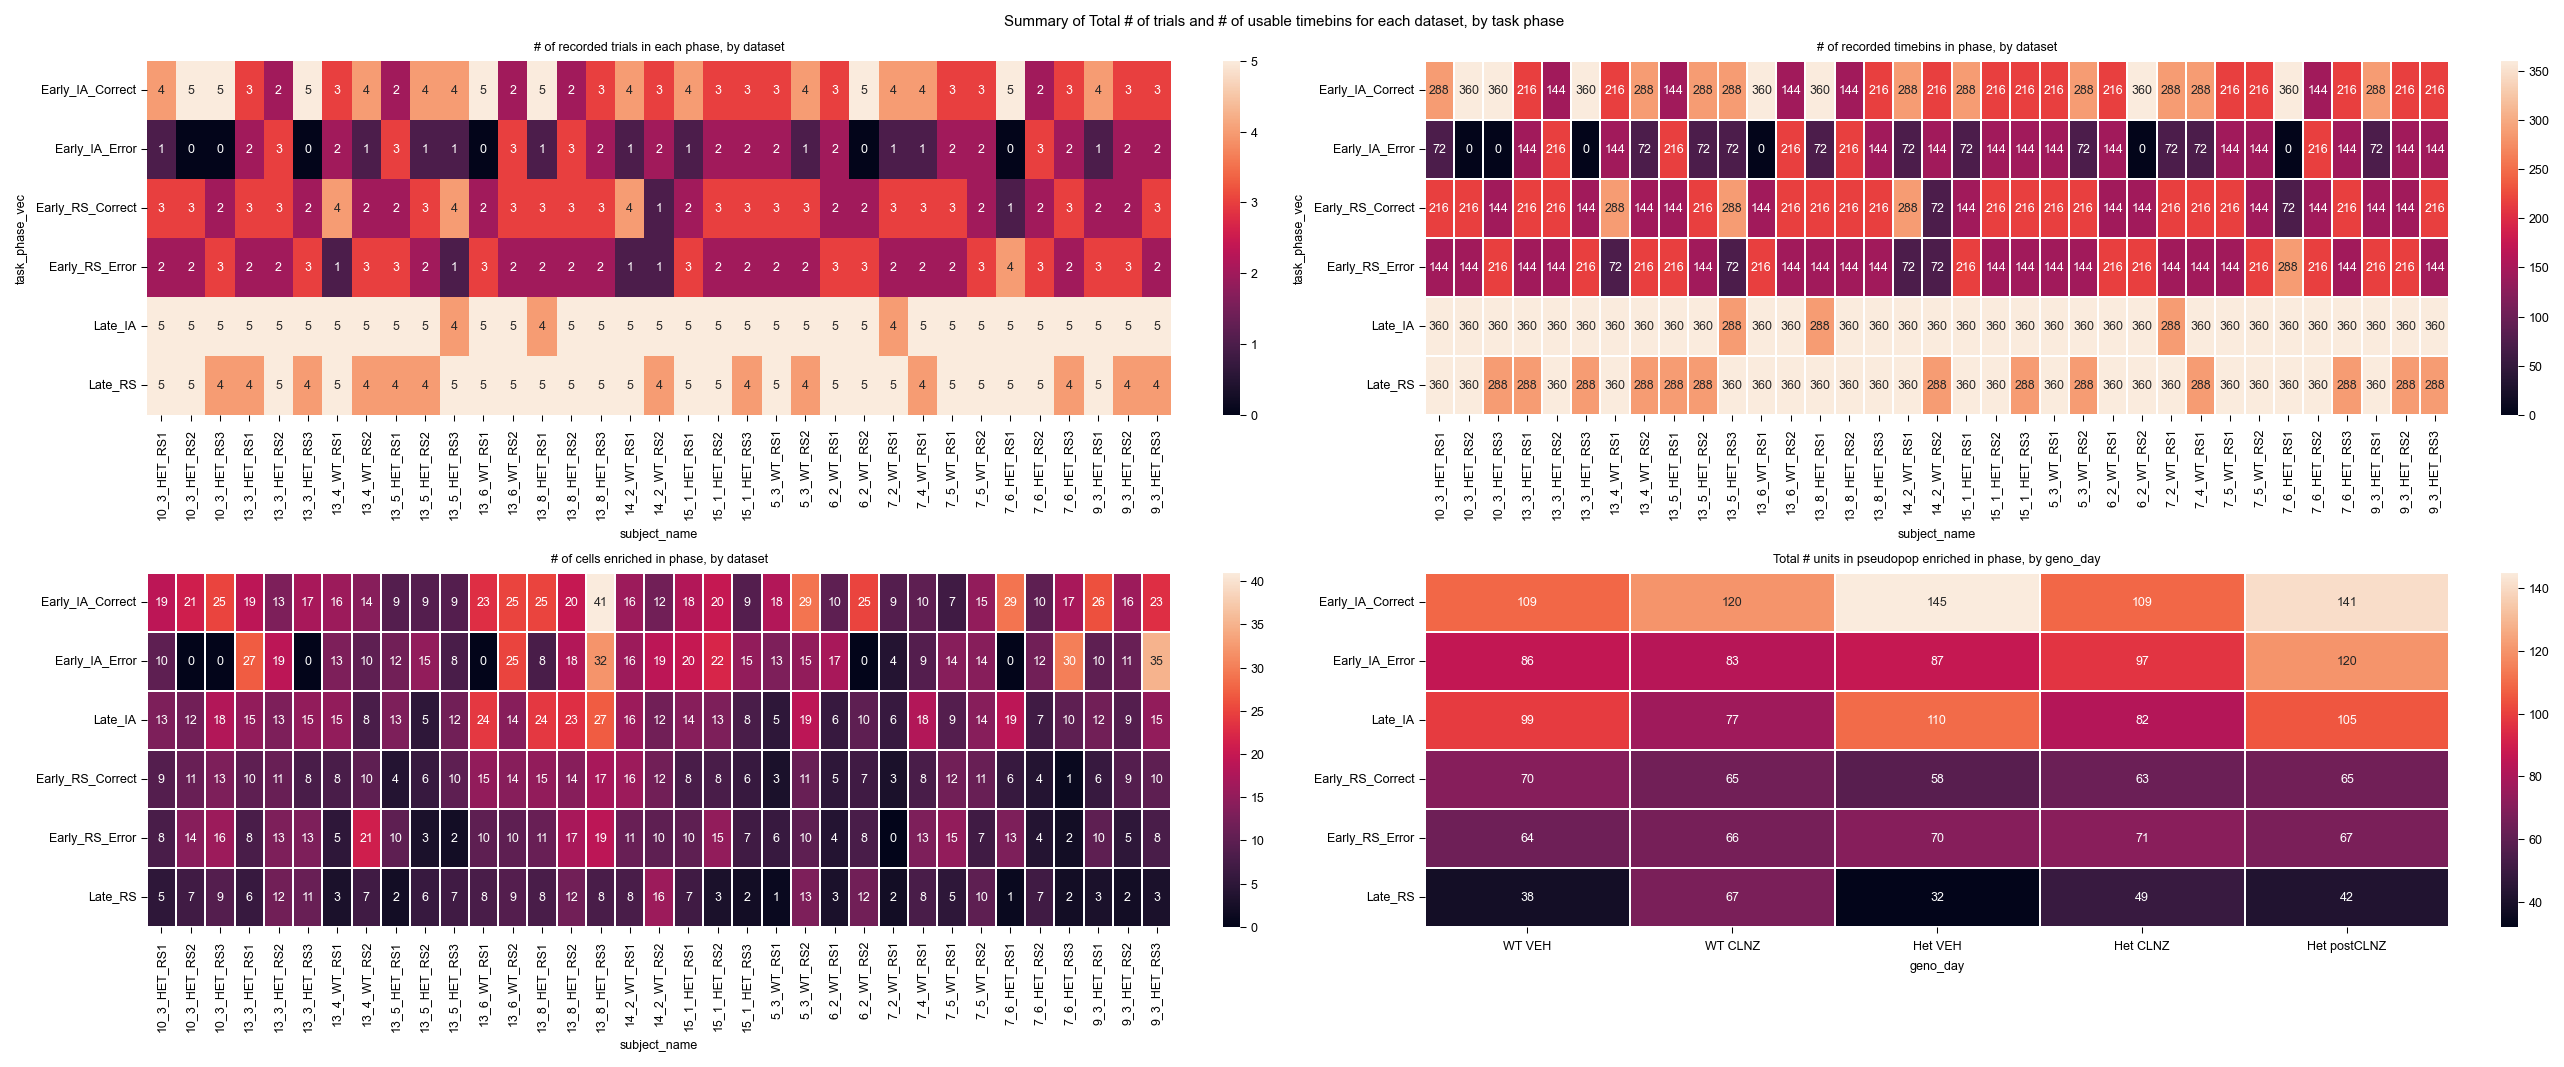

In [49]:

#gather trial types
trial_type_by_subj = get_num_trials_by_type_in_subject(single_trial_tseries_w_enrich, task_phase_col= 'task_phase_vec', name_col = subject_col).fillna(0);
trial_type_by_subj[phase_names] = trial_type_by_subj[phase_names].astype(int)
neuron_enrichment =  single_trial_tseries_w_enrich.groupby([subject_col, 'geno_day', id_col])[phase_names].mean().reset_index()
phase_enrichment_by_subj = neuron_enrichment[list(phase_names) + [subject_col, 'geno_day']].groupby(by = [subject_col, 'geno_day']).sum().reset_index()

#make figures
unit_count_fig, axs = plot_unit_enrich_by_phase_summary((17,7), trial_type_by_subj,phase_enrichment_by_subj,geno_order_w_WT_CLNZ, phase_names,numeric_col, name_col = subject_col)
#save as a fig
pdf_name = output_folder / Path(f"Enrichment of {units} and # of samples per phase")
save_fig_as_filetype_list(unit_count_fig, pdf_name , subfolder_names, ['pdf', 'png'])

In [50]:
neuron_enrichment[neuron_enrichment['subject_name'] == '10_3_HET_RS2']

,subject_name,geno_day,neuron_ID,Early_IA_Correct,Early_IA_Error,Late_IA,Early_RS_Correct,Early_RS_Error,Late_RS
97,10_3_HET_RS2,Het CLNZ,10_3_HET_RS2-10,1.0,NaN,0.0,0.0,0.0,0.0
98,10_3_HET_RS2,Het CLNZ,10_3_HET_RS2-101,0.0,NaN,0.0,0.0,0.0,0.0
99,10_3_HET_RS2,Het CLNZ,10_3_HET_RS2-102,0.0,NaN,0.0,0.0,0.0,0.0
100,10_3_HET_RS2,Het CLNZ,10_3_HET_RS2-104,0.0,NaN,0.0,0.0,0.0,1.0
101,10_3_HET_RS2,Het CLNZ,10_3_HET_RS2-105,1.0,NaN,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
216,10_3_HET_RS2,Het CLNZ,10_3_HET_RS2-92,0.0,NaN,0.0,0.0,0.0,0.0
217,10_3_HET_RS2,Het CLNZ,10_3_HET_RS2-95,0.0,NaN,0.0,0.0,0.0,0.0
218,10_3_HET_RS2,Het CLNZ,10_3_HET_RS2-97,0.0,NaN,0.0,0.0,0.0,0.0
219,10_3_HET_RS2,Het CLNZ,10_3_HET_RS2-98,0.0,NaN,0.0,0.0,0.0,0.0


### New Pseudopop generation by resampling cell activity time-series

In [51]:
#imported from autoencoder:
# ## helper functions imported from phase_enrich_timeseries_decode.py module
def get_dataset_names_in_geno(dataset_name_by_geno_day,
                              geno_day,
                              subject_name_col = 'subject_name'):
    datasets_in_geno = dataset_name_by_geno_day.loc[dataset_name_by_geno_day.geno_day == geno_day,subject_name_col].values[0] #get name of datasets in current geno_day setup
    return datasets_in_geno

 ## imported subfunc for cuDF speedup
def get_tseries_of_dataset(timeseries_df, 
                           dataset_name, 
                           subject_name_col = 'subject_name'):
    #get time-series that are occurign in phase of interest
    dataset_df_slice = timeseries_df.loc[timeseries_df[subject_name_col] == dataset_name]
    return dataset_df_slice

def get_tseries_in_phase(timeseries_df, phase_name):
    phase_dataset_df_slice = timeseries_df.loc[timeseries_df.task_phase_vec == phase_name]
    return phase_dataset_df_slice

def get_tseries_phase_enrich_cells(tseries_df, unit_ID_col, enrichment_ID_df, dataset_name, e_phase_name,subject_name_col = 'subject_name'):
    enrich_in_phase_unit_IDs = get_dataset_units_enrich_in_phase(enrichment_ID_df, unit_ID_col, dataset_name, e_phase_name, subject_name_col = subject_name_col) #get unit IDs that are enriched in phase of interest
    enrich_in_phase_dataset_df = tseries_df.loc[tseries_df[unit_ID_col].isin(enrich_in_phase_unit_IDs)]#get unit time-series only if they enriched in phase of interest
    return enrich_in_phase_dataset_df, enrich_in_phase_unit_IDs

def get_dataset_units_enrich_in_phase(enrich_unit_by_name_phase_df,
                                       unit_ID_col,
                                         dataset_name,
                                           stage_of_interest,
                                           subject_name_col = 'subject_name'):
    name_mask = enrich_unit_by_name_phase_df[subject_name_col] == dataset_name
    phase_mask = enrich_unit_by_name_phase_df.task_phase_vec == stage_of_interest
    enrich_in_phase_unit_IDs =enrich_unit_by_name_phase_df.loc[phase_mask&name_mask, unit_ID_col].values[0]
    return enrich_in_phase_unit_IDs

def horzcat_all_trials(timeseries_df, tseries_cols, unit_col_name, drop_pre_outcome=False):
    if drop_pre_outcome:
        print("drop pre outcome called")
        tseries_cols = [col for col in tseries_cols if "-" not in col]
    grouped = {
        trial: group.set_index(unit_col_name)[tseries_cols]
        for trial, group in timeseries_df.groupby('trial_num', sort=False)
    }
    return pd.concat(grouped.values(), axis=1)

def horzcat_all_trials_original(timeseries_df, tseries_cols, unit_col_name, drop_pre_outcome=False):
    if drop_pre_outcome:
        tseries_cols = [col for col in tseries_cols if "-" not in col] 
    trial_slice_storage = []
    for trial in timeseries_df.trial_num.unique():
        trial_slice = timeseries_df.loc[timeseries_df.trial_num == trial].set_index(unit_col_name)
        trial_slice_storage.append(trial_slice.loc[:,tseries_cols])
    return pd.concat(trial_slice_storage, axis=1)

# Test
result_orig = horzcat_all_trials_original(trial_tseries_df_norm, numeric_col,unit_ID_col)
result_opt = horzcat_all_trials(trial_tseries_df_norm, numeric_col,unit_ID_col)

print("Identical:", result_orig.equals(result_opt))
print("Shape match:", result_orig.shape == result_opt.shape)
print("Columns match:", list(result_orig.columns) == list(result_opt.columns))
print("Index match:", list(result_orig.index) == list(result_opt.index))

def make_dataset_matrix_store_only(phase_names, 
                                   trial_tseries_df_norm,
                                   unit_ID_col,
                                   enrich_unit_ID_by_name_df,
                                    numeric_col,
                                    trial_list_by_dataset,
                                   dataset_name_by_geno_day,
                                   phase_enrichment_by_subj,
                                     subject_name_col = 'subject_name'):
    """TO- create a dict where key1 = stage the pseudopop is enriched in, key 2 = stage to look for activity of, and key 3- genotype of current datset"""
    ppop_data,stage_geno_tseries = dict(), dict()
    iter_ct = 0
    for e_phase in phase_names:
        ppop_data[e_phase],stage_geno_tseries[e_phase] = {},{}
        print("Get enrich in ",e_phase, "act. in ", phase_names)

        for act_phase in phase_names:
            datasets_w_phase_act = trial_list_by_dataset.loc[trial_list_by_dataset.task_phase_vec == act_phase][subject_name_col].unique()
            ppop_data[e_phase][act_phase],stage_geno_tseries[e_phase][act_phase]= {},{}

            for geno_day in dataset_name_by_geno_day.geno_day.unique():
                datasets_in_geno = get_dataset_names_in_geno(dataset_name_by_geno_day,geno_day, subject_name_col = subject_name_col)
                geno_dataset_w_act = [name for name in datasets_in_geno if name in datasets_w_phase_act]
                current_ppop_draw = dict()
                
                for dataset in geno_dataset_w_act:
                    iter_ct = iter_ct+1
                    #check if > 0 cells are enriched in stage
                    if phase_enrichment_by_subj.set_index(subject_name_col).loc[dataset, e_phase] > 0:
                        phase_dataset_df = get_tseries_in_phase(get_tseries_of_dataset(trial_tseries_df_norm,dataset, subject_name_col = subject_name_col), act_phase)
                        e_in_phase_data_df,e_in_stage_ID =get_tseries_phase_enrich_cells(phase_dataset_df, unit_ID_col,
                                                                                         enrich_unit_ID_by_name_df, dataset, e_phase, subject_name_col = subject_name_col)
                        current_ppop_draw[dataset] =  horzcat_all_trials_original(e_in_phase_data_df,numeric_col, unit_ID_col)
                ppop_data[e_phase][act_phase][geno_day] =current_ppop_draw
    return ppop_data

Identical: True
Shape match: True
Columns match: True
Index match: True


#### Get all time-series corresponding to dataset N

In [52]:
single_trial_tseries_w_enrich= single_trial_tseries_w_enrich.assign(**{'any_enrichment':  single_trial_tseries_w_enrich[phase_names].sum(axis = 1)})

trial_list_by_dataset = get_trial_num_in_phase_by_dataset( single_trial_tseries_w_enrich, name_col = subject_col)
##important- threshold to take datasets with >1 trials per section ( to have enough space of neurons)
trial_list_by_dataset= trial_list_by_dataset[trial_list_by_dataset.count_of_trials >1]
enrich_unit_ID_by_name_df =get_ID_enriched_units_by_phase(single_trial_tseries_w_enrich, ID_col= unit_ID_col, bool_col_tseries_enriched = 'enriched_in_phase', subj_name_col = subject_col )
dataset_name_by_geno_day = enrich_unit_ID_by_name_df.groupby('geno_day')[subject_col].unique().reset_index()
#add unique identifier that's (dataset_name + neuron_ID) to retain neuron ID info

In [53]:
single_trial_tseries_w_enrich.head()

,task_phase_vec,IA_RS_vec,corr_err_vec,trial_num,neuron_ID,section,subject_name,session,raw_ID,day,...,pvalue_post_outcome_Late_RS,Run_end_time,num_shuffles,any_enrichment,enriched_in_phase,normalized,max_trial_val_all_time,min_max_type,mean_rate_in_trial,cell_is_active_in_trial
0,Early_IA_Correct,IA,Correct,1,10_3_HET_RS1-1,post_outcome,10_3_HET_RS1,RS1,1,1,...,1.0000,30-Jan-2026 17:20:28,10000,1.0,False,none,1.0,all_frames,0.00,False
2,Early_IA_Correct,IA,Correct,1,10_3_HET_RS1-3,post_outcome,10_3_HET_RS1,RS1,3,1,...,0.3656,30-Jan-2026 17:20:28,10000,1.0,False,none,1.0,all_frames,0.00,False
3,Early_IA_Correct,IA,Correct,1,10_3_HET_RS1-4,post_outcome,10_3_HET_RS1,RS1,4,1,...,1.0000,30-Jan-2026 17:20:28,10000,1.0,False,none,1.0,all_frames,0.00,False
4,Early_IA_Correct,IA,Correct,1,10_3_HET_RS1-5,post_outcome,10_3_HET_RS1,RS1,5,1,...,1.0000,30-Jan-2026 17:20:28,10000,0.0,False,none,1.0,all_frames,0.29,True
5,Early_IA_Correct,IA,Correct,1,10_3_HET_RS1-6,post_outcome,10_3_HET_RS1,RS1,6,1,...,0.1980,30-Jan-2026 17:20:28,10000,0.0,False,none,1.0,all_frames,0.00,False


In [54]:
enrich_unit_ID_by_name_df.tail()

,subject_name,geno_day,task_phase_vec,neuron_ID,num_enriched_units
198,9_3_HET_RS3,Het postCLNZ,Early_IA_Error,"[9_3_HET_RS3-6, 9_3_HET_RS3-9, 9_3_HET_RS3-12,...",35
199,9_3_HET_RS3,Het postCLNZ,Early_RS_Correct,"[9_3_HET_RS3-40, 9_3_HET_RS3-62, 9_3_HET_RS3-7...",10
200,9_3_HET_RS3,Het postCLNZ,Early_RS_Error,"[9_3_HET_RS3-25, 9_3_HET_RS3-45, 9_3_HET_RS3-6...",8
201,9_3_HET_RS3,Het postCLNZ,Late_IA,"[9_3_HET_RS3-4, 9_3_HET_RS3-9, 9_3_HET_RS3-25,...",15
202,9_3_HET_RS3,Het postCLNZ,Late_RS,"[9_3_HET_RS3-3, 9_3_HET_RS3-130, 9_3_HET_RS3-214]",3


## Set What decoding to run:

In [55]:
run_activity_save = False
run_binary_SVM = False
run_CCGP_base = False
run_CCGP_permuted = False
run_timedep = False
## new for revisions-
run_allcell_ccgp = False
run_allcell_ccgp_permuted = False
run_CCGP_activity_match = False

## new for revisions v2-
run_single_mouse_ccgp = True


#### Make full cell draw for whole pop decoding run

In [56]:
## create value stores for FULL CELL DRAW
subject_name_col = 'subject_name'
all_cell_store,stage_geno_tseries= {},{}
## loop throuhg all phases
iter_ct = 0
for act_phase in phase_names:
    print(f"Get all cell activity in {act_phase}")
    datasets_w_phase_act = trial_list_by_dataset.loc[trial_list_by_dataset.task_phase_vec == act_phase][subject_name_col].unique()
    
    all_cell_store[act_phase],stage_geno_tseries[act_phase]= {},{}

    for geno_day in dataset_name_by_geno_day.geno_day.unique():
        datasets_in_geno = get_dataset_names_in_geno(dataset_name_by_geno_day,geno_day, subject_name_col = subject_name_col)
        geno_dataset_w_act = [name for name in datasets_in_geno if name in datasets_w_phase_act]
        current_ppop_draw = dict()
        
        for dataset in geno_dataset_w_act:
            iter_ct = iter_ct+1
            #check if > 0 cells are enriched in stage
            phase_dataset_df = get_tseries_in_phase(get_tseries_of_dataset(trial_tseries_df_norm,dataset, subject_name_col = subject_name_col), act_phase)    

            current_ppop_draw[dataset] =  horzcat_all_trials_original(phase_dataset_df,numeric_col, unit_ID_col)

        all_cell_store[act_phase][geno_day] =current_ppop_draw

Get all cell activity in Early_IA_Correct
Get all cell activity in Early_IA_Error
Get all cell activity in Late_IA
Get all cell activity in Early_RS_Correct
Get all cell activity in Early_RS_Error
Get all cell activity in Late_RS


In [57]:
## print size of data store to verify
for act_phase in phase_names:
    for geno_day in dataset_name_by_geno_day.geno_day.unique():
        print(f"phase {act_phase}, geno_day {geno_day}, # datasets: {len(all_cell_store[act_phase][geno_day])}")
        for subj in all_cell_store[act_phase][geno_day].keys():
            # get n unique cells in here 
            slice_data = all_cell_store[act_phase][geno_day][subj]
            trial_mask = (trial_tseries_df_norm['task_phase_vec'] == act_phase) & (trial_tseries_df_norm['geno_day'] == geno_day) & (trial_tseries_df_norm['subject_name'] == subj)
            n_unique_cells = trial_tseries_df_norm.loc[trial_mask,'neuron_ID'].nunique()
            slice_shape = slice_data.shape
            print(f"key: {"_".join([act_phase,geno_day,subj])}, {n_unique_cells} unique cells, shaped: {slice_shape}.")
            print(len(set(slice_data.columns)))
            assert n_unique_cells == slice_shape[0]
            assert slice_shape[1] % 72 == 0
        
all_cell_store

phase Early_IA_Correct, geno_day Het CLNZ, # datasets: 7
key: Early_IA_Correct_Het CLNZ_10_3_HET_RS2, 124 unique cells, shaped: (124, 360).
72
key: Early_IA_Correct_Het CLNZ_13_3_HET_RS2, 106 unique cells, shaped: (106, 144).
72
key: Early_IA_Correct_Het CLNZ_13_5_HET_RS2, 118 unique cells, shaped: (118, 288).
72
key: Early_IA_Correct_Het CLNZ_13_8_HET_RS2, 135 unique cells, shaped: (135, 144).
72
key: Early_IA_Correct_Het CLNZ_15_1_HET_RS2, 167 unique cells, shaped: (167, 216).
72
key: Early_IA_Correct_Het CLNZ_7_6_HET_RS2, 107 unique cells, shaped: (107, 144).
72
key: Early_IA_Correct_Het CLNZ_9_3_HET_RS2, 109 unique cells, shaped: (109, 216).
72
phase Early_IA_Correct, geno_day Het VEH, # datasets: 7
key: Early_IA_Correct_Het VEH_10_3_HET_RS1, 97 unique cells, shaped: (97, 288).
72
key: Early_IA_Correct_Het VEH_13_3_HET_RS1, 121 unique cells, shaped: (121, 216).
72
key: Early_IA_Correct_Het VEH_13_5_HET_RS1, 114 unique cells, shaped: (114, 144).
72
key: Early_IA_Correct_Het VEH_13_8

{'Early_IA_Correct': {'Het CLNZ': {'10_3_HET_RS2':                   -3.0s to -2.75s  -2.75s to -2.5s  -2.5s to -2.25s  \
   neuron_ID                                                             
   10_3_HET_RS2-2                0.0              0.0              0.0   
   10_3_HET_RS2-3                0.0              0.0              0.0   
   10_3_HET_RS2-5                0.0              0.0              0.0   
   10_3_HET_RS2-6                0.0              0.0              0.0   
   10_3_HET_RS2-7                0.0              0.0              0.0   
   ...                           ...              ...              ...   
   10_3_HET_RS2-160              0.0              0.0              0.0   
   10_3_HET_RS2-162              0.0              0.0              0.0   
   10_3_HET_RS2-163              0.0              0.0              0.0   
   10_3_HET_RS2-166              0.0              0.0              0.0   
   10_3_HET_RS2-167              0.0              0.0           

#### package all real enrichewd cell activations for future use

In [58]:
id_col = [col for col in single_trial_tseries_w_enrich.columns if 'id' in col.lower()][0]
print(id_col)

neuron_ID


In [59]:
## make real dataset storage
dataset_name_by_geno_day
phase_enrichment_by_subj
class_matrix_store  = make_dataset_matrix_store_only(phase_names, 
                                                     single_trial_tseries_w_enrich,
                                                     unit_ID_col,
                                                     enrich_unit_ID_by_name_df,
                                                       numeric_col,
                                                         trial_list_by_dataset,
                                                         dataset_name_by_geno_day,
                                                         phase_enrichment_by_subj,
                                                         subject_name_col = subject_col,
                                                          )

Get enrich in  Early_IA_Correct act. in  ['Early_IA_Correct' 'Early_IA_Error' 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']
Get enrich in  Early_IA_Error act. in  ['Early_IA_Correct' 'Early_IA_Error' 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']
Get enrich in  Late_IA act. in  ['Early_IA_Correct' 'Early_IA_Error' 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']
Get enrich in  Early_RS_Correct act. in  ['Early_IA_Correct' 'Early_IA_Error' 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']
Get enrich in  Early_RS_Error act. in  ['Early_IA_Correct' 'Early_IA_Error' 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']
Get enrich in  Late_RS act. in  ['Early_IA_Correct' 'Early_IA_Error' 'Late_IA' 'Early_RS_Correct'
 'Early_RS_Error' 'Late_RS']


In [60]:
class_matrix_store.keys()

dict_keys(['Early_IA_Correct', 'Early_IA_Error', 'Late_IA', 'Early_RS_Correct', 'Early_RS_Error', 'Late_RS'])

In [61]:
class_matrix_store['Early_IA_Correct']

{'Early_IA_Correct': {'Het CLNZ': {'10_3_HET_RS2':                   -3.0s to -2.75s  -2.75s to -2.5s  -2.5s to -2.25s  \
   neuron_ID                                                             
   10_3_HET_RS2-5                0.0              0.0              0.0   
   10_3_HET_RS2-10               0.0              0.0              0.0   
   10_3_HET_RS2-12               0.0              0.0              0.0   
   10_3_HET_RS2-21               0.0              1.0              0.4   
   10_3_HET_RS2-27               0.0              0.0              0.0   
   10_3_HET_RS2-34               1.0              1.0              1.0   
   10_3_HET_RS2-44               0.0              0.0              0.0   
   10_3_HET_RS2-56               0.0              0.0              0.0   
   10_3_HET_RS2-60               0.0              0.0              0.4   
   10_3_HET_RS2-69               0.6              0.4              0.8   
   10_3_HET_RS2-90               1.0              1.0           

In [62]:
numeric_col

Index(['-3.0s to -2.75s', '-2.75s to -2.5s', '-2.5s to -2.25s',
       '-2.25s to -2.0s', '-2.0s to -1.75s', '-1.75s to -1.5s',
       '-1.5s to -1.25s', '-1.25s to -1.0s', '-1.0s to -0.75s',
       '-0.75s to -0.5s', '-0.5s to -0.25s', '-0.25s to -0.0s',
       '0.0s to 0.25s', '0.25s to 0.5s', '0.5s to 0.75s', '0.75s to 1.0s',
       '1.0s to 1.25s', '1.25s to 1.5s', '1.5s to 1.75s', '1.75s to 2.0s',
       '2.0s to 2.25s', '2.25s to 2.5s', '2.5s to 2.75s', '2.75s to 3.0s',
       '3.0s to 3.25s', '3.25s to 3.5s', '3.5s to 3.75s', '3.75s to 4.0s',
       '4.0s to 4.25s', '4.25s to 4.5s', '4.5s to 4.75s', '4.75s to 5.0s',
       '5.0s to 5.25s', '5.25s to 5.5s', '5.5s to 5.75s', '5.75s to 6.0s',
       '6.0s to 6.25s', '6.25s to 6.5s', '6.5s to 6.75s', '6.75s to 7.0s',
       '7.0s to 7.25s', '7.25s to 7.5s', '7.5s to 7.75s', '7.75s to 8.0s',
       '8.0s to 8.25s', '8.25s to 8.5s', '8.5s to 8.75s', '8.75s to 9.0s',
       '9.0s to 9.25s', '9.25s to 9.5s', '9.5s to 9.75s', '9.75s to 1

#### New- save out of distrib activation matrices and cell IDs

In [63]:
from matrix_resample_utils import resample_into_class_matrix,  resample_combine_dict_of_activity_dfs,fast_pack_data_local 
from fixed_decoder_alignment import align_train_test_matrices #set-intersection unit alignment

In [64]:
# Script to record cells and mean activity per class for out-of-distribution decoding

#create out of distribution handles
out_of_dist_train_sets = [
    [phase_names[0], phase_names[3]],#train on- early IA corr vs. early RS corr
     [phase_names[1], phase_names[4]],#train on- early IA err vs.l early RS err
    [phase_names[0], phase_names[1]],#train on-early IA corr vs. early IA err
    [phase_names[3], phase_names[4]],#train on- early RS corr vs. early RS err
    ]
out_of_dist_test_sets = [
    [phase_names[1], phase_names[4]],#test on- early IA err vs.l early RS err
    [phase_names[0], phase_names[3]],#test on- early IA corr vs. early RS corr
    [phase_names[3], phase_names[4]],##test on- early RS corr vs. early RS err
    [phase_names[0], phase_names[1]],##test on- early IA corr vs. early IA err
    ]
print(f"train sets: {out_of_dist_train_sets}")
print(f"Test sets: {out_of_dist_test_sets}")
print(f"train sets: {out_of_dist_train_sets}")
print(f"Test sets: {out_of_dist_test_sets}")

cell_activity_records = []
num_resample = 400
reg_penalty = 'l2'

n_activity_bootstraps = 1000

k_folds = 4 #first iter is 5 fold cv
test_size = 0.25 #new test size
## set
phase_keys = class_matrix_store.keys()


if run_activity_save:
    for n_run in range(n_activity_bootstraps):
        for e_phase in phase_keys:
            for geno_day_curr in class_matrix_store['Late_RS']['Late_RS'].keys():
                # Resample into class matrices
                ensemble_resample_in_phase_dict = {}
                for class_name in phase_keys:
                    class_matrix = resample_into_class_matrix(class_matrix_store, num_resample, e_phase, class_name, geno_day_curr)
                    ensemble_resample_in_phase_dict[class_name] = class_matrix

                for phase_count, phase_pair in enumerate(out_of_dist_train_sets):
                    class_0_train, class_1_train = phase_pair[0], phase_pair[1]
                    test_pair = out_of_dist_test_sets[phase_count]
                    class_0_test, class_1_test = test_pair[0], test_pair[1]

                    # Build train matrix
                    class_mat_0_train = ensemble_resample_in_phase_dict[class_0_train]
                    class_mat_1_train = ensemble_resample_in_phase_dict[class_1_train]
                    concat_matrix_train, concat_labels_train = fast_pack_data_local(class_mat_0_train, class_mat_1_train, 0, 1)

                    # Build test matrix
                    class_mat_0_test = ensemble_resample_in_phase_dict[class_0_test]
                    class_mat_1_test = ensemble_resample_in_phase_dict[class_1_test]
                    concat_matrix_test, concat_labels_test = fast_pack_data_local(class_mat_0_test, class_mat_1_test, 0, 1)

                    # Get cell IDs
                    unit_IDs_test = concat_matrix_test.index.values
                    unit_IDs_train = concat_matrix_train.index.values

                    # Filter to cells present in both
                    train_IDs_in_test_bool = [u in unit_IDs_test for u in unit_IDs_train]
                    test_IDs_in_train_bool = [u in unit_IDs_train for u in unit_IDs_test]

                    # Common cells
                    common_cell_ids = unit_IDs_train[train_IDs_in_test_bool]

                    # Pivot and filter matrices
                    concat_matrix_test_arr = concat_matrix_test.T.values[:, test_IDs_in_train_bool]
                    concat_matrix_train_arr = concat_matrix_train.T.values[:, train_IDs_in_test_bool]

                    # Mean activity per class per cell
                    mean_activity = {
                        'c0_train_mean': concat_matrix_train_arr[concat_labels_train == 0].mean(axis=0).astype(np.float16),
                        'c1_train_mean': concat_matrix_train_arr[concat_labels_train == 1].mean(axis=0).astype(np.float16),
                        'c0_test_mean': concat_matrix_test_arr[concat_labels_test == 0].mean(axis=0).astype(np.float16),
                        'c1_test_mean': concat_matrix_test_arr[concat_labels_test == 1].mean(axis=0).astype(np.float16),
                    }

                    record_key = f"{n_run}_{e_phase}_{geno_day_curr}_{class_0_train}_{class_1_train}_to_{class_0_test}_{class_1_test}"
                    
                    cell_activity_records.append({
                        'record_key': record_key,
                        'pseudopop_run': n_run,
                        'ensemble': e_phase,
                        'geno_day': geno_day_curr,
                        'train_on': f"{class_0_train}_{class_1_train}",
                        'test_on': f"{class_0_test}_{class_1_test}",
                        'cell_ids': common_cell_ids,
                        'n_cells': len(common_cell_ids),
                        **mean_activity
                    })

    cell_activity_df = pd.DataFrame.from_records(cell_activity_records)
    print(f"Recorded {len(cell_activity_df)} combinations")
    cell_activity_file_name = output_folder / Path(f"Cell Activity (Out of Distrib) {n_activity_bootstraps} pseudopop {data_type} {date_tag}.parquet")
    cell_activity_df.to_parquet(cell_activity_file_name, compression='snappy')
    print(f"cell activity file name: {cell_activity_file_name}")
    cell_activity_df.head()

train sets: [['Early_IA_Correct', 'Early_RS_Correct'], ['Early_IA_Error', 'Early_RS_Error'], ['Early_IA_Correct', 'Early_IA_Error'], ['Early_RS_Correct', 'Early_RS_Error']]
Test sets: [['Early_IA_Error', 'Early_RS_Error'], ['Early_IA_Correct', 'Early_RS_Correct'], ['Early_RS_Correct', 'Early_RS_Error'], ['Early_IA_Correct', 'Early_IA_Error']]
train sets: [['Early_IA_Correct', 'Early_RS_Correct'], ['Early_IA_Error', 'Early_RS_Error'], ['Early_IA_Correct', 'Early_IA_Error'], ['Early_RS_Correct', 'Early_RS_Error']]
Test sets: [['Early_IA_Error', 'Early_RS_Error'], ['Early_IA_Correct', 'Early_RS_Correct'], ['Early_RS_Correct', 'Early_RS_Error'], ['Early_IA_Correct', 'Early_IA_Error']]


## Binary SVM decoder

In [65]:
def get_test_precision_recall_acc(test_set_data, test_set_labels, trained_model):
#TO- given model already trained on test set, create prediction vec, then calculate precision and recall
    prediction_vec =trained_model.predict(test_set_data)
    true_positive_vec = test_set_labels*prediction_vec
    ## get score metrics
    precision = (1+np.sum(true_positive_vec))/(1+ np.sum(prediction_vec)) #precision = % of predicted 1 / true 1
    recall = (1+ np.sum(true_positive_vec))/ (1+np.sum(test_set_labels)) #recall =  % of predicted 1/ all 1
    acc = np.mean(prediction_vec == test_set_labels)
    return precision, recall,acc


## new- get cosine sim of class matrices:
def mean_class_cosine_sim(matrix, labels):
    """Cosine similarity between mean vectors of class 0 and class 1."""
    mean_0 = matrix[labels == 0].mean(axis=0)
    mean_1 = matrix[labels == 1].mean(axis=0)
    return np.dot(mean_0, mean_1) / (np.linalg.norm(mean_0) * np.linalg.norm(mean_1))

In [66]:


def run_N_stage_pair_decoders(class_matrix_store,class_comparisons, num_resample, test_size = 0.5, k_folds = 2, n_pseudopop_run_range = [0]):
    """To- given a predefined range of numbers to uterate over as run #s, run SVM decoding thoese N times on ensemble, stage, and geno-day pairs  """
    all_run_record_store = []#create storage for all run information for later concat
    weight_records = []  # Storage for SVM weights and cell IDs
    #declare variables for local use
    reg_penalty = 'l2'
    
    phase_names = class_matrix_store.keys()
    for n_run in n_pseudopop_run_range:
        for e_phase in phase_names:#set enrichment type to use# e_phase = "Early_IA_Correct" #100 perms- 7 min for all activity x geno_day groups per e-phase iter
            for geno_day_curr in class_matrix_store['Late_RS']['Late_RS'].keys(): #set geno to use
                ensemble_resample_in_phase_dict = {}
                for class_name in phase_names:
                    class_matrix = resample_into_class_matrix(class_matrix_store,num_resample, e_phase, class_name, geno_day_curr)
                    ensemble_resample_in_phase_dict[class_name] = class_matrix
                
                for phase_count, phase_pair in enumerate(class_comparisons): #once genotype & enrichment filter, specified, compare phase detection
                    class_0,class_1 = phase_pair[0], phase_pair[1] # print(f"{geno_day_curr}, {e_phase}-enriched units decode: {phase_pair}")
                    ## make training set
                    class_mat_0 =ensemble_resample_in_phase_dict[class_0]
                    class_mat_1 =ensemble_resample_in_phase_dict[class_1]
                    concat_matrix,concat_labels =fast_pack_data_local(class_mat_0, class_mat_1,0,1)        #returns concat_matrix, and concat_labels
                    cell_ids = concat_matrix.index.values  # Capture cell IDs BEFORE .T.values
                    concat_matrix = concat_matrix.T.values #.T.values of concat matrix is to reshape mat into what scikit wants from you
                    
                    cv = model_selection.StratifiedShuffleSplit(n_splits = k_folds, test_size =test_size)#Create CV object do leave one out split using minority class indices
                    target_info = {"pseudopop_run_num": n_run, 'class_0': class_0,'class_1' : class_1,"enriched_group": e_phase, 'geno_day': geno_day_curr} #speficy info about what classes being decoded
                    # split_accuracy = [] #NOW, ONLY TAKE ACCURACY OF EACH SPLIT AND AVERAGE IT OVER SPLITS 
                    full_cosine_sim = mean_class_cosine_sim(concat_matrix, concat_labels).astype(np.float16)

                    for split_count, (train, test) in enumerate(cv.split(np.zeros(len(concat_labels)), concat_labels)):
                        model = svm.LinearSVC(C= 1, max_iter=1000, penalty=reg_penalty, dual=False, verbose= 0) #make new model per geno_day classifier split
                        trained_model = model.fit(concat_matrix[train,:], concat_labels[train])                 # score_real = trained_model.score( concat_matrix[test,:], concat_labels[test])#get accuracy
                        #get accuracy
                        prediction_vec =trained_model.predict(concat_matrix[test,:])
                        true_pos= np.sum([np.array([prediction_vec == 1]) &  np.array([concat_labels[test]==1])])
                        true_neg= np.sum([np.array([prediction_vec == 0]) &  np.array([concat_labels[test]==0])])
                        false_pos =  np.sum([np.array([prediction_vec == 1]) &  np.array([concat_labels[test]==0])])
                        false_neg =  np.sum([np.array([prediction_vec == 0]) &  np.array([concat_labels[test]==1])])
                        score_real = np.mean(prediction_vec == concat_labels[test])
                        
                        # Calculate cosine similarity between mean class vectors (using training & test data)
                        train_cosine_sim = mean_class_cosine_sim(concat_matrix[train], concat_labels[train]).astype(np.float16)
                        test_cosine_sim = mean_class_cosine_sim(concat_matrix[test], concat_labels[test]).astype(np.float16)

                        # Create unique decoder key for linking weights
                        decoder_key = f"{n_run}_{e_phase}_{geno_day_curr}_{class_0}_{class_1}_{split_count}"
                        
                        # Store weights and cell IDs
                        weight_records.append({
                            'decoder_key': decoder_key,
                            'weights': trained_model.coef_.flatten().astype(np.float16),
                            'cell_ids': cell_ids,
                            'intercept': trained_model.intercept_[0],
                            'train_class_0_mean': np.mean(concat_matrix[train][concat_labels[train] == 0], axis=0).astype(np.float16),
                            'train_class_1_mean': np.mean(concat_matrix[train][concat_labels[train] == 1], axis=0).astype(np.float16),
                            'test_class_0_mean': np.mean(concat_matrix[test][concat_labels[test] == 0], axis=0).astype(np.float16),
                            'test_class_1_mean': np.mean(concat_matrix[test][concat_labels[test] == 1], axis=0).astype(np.float16),
                        })

                        # precision, recall,score_real = get_test_precision_recall_acc( concat_matrix[test,:], concat_labels[test], trained_model)
                        curr_split_params = {**target_info,
                        'split': split_count, 
                        'accuracy': score_real.astype(np.float16),
                                             'decoder_key': decoder_key,  # Add key for linking to weights
                                             'num_features_used': trained_model.n_features_in_, 'num_nonzero_coef': np.sum(np.abs(trained_model.coef_)>0), 
                                             'train_pos_sample':  np.sum(concat_labels[train] ==1), 'train_neg_sample':np.sum(concat_labels[train] ==0),
                                             'test_pos_sample':np.sum(concat_labels[test]==1), 'test_neg_sample': np.sum(concat_labels[test]==0),
                                            'true_pos': true_pos,'true_neg':true_neg,'false_pos':false_pos, 'false_neg' :false_neg,
                                            'train_cosine_sim': train_cosine_sim, 
                                            'test_cosine_sim': test_cosine_sim,
                                              'full_cosine_sim': full_cosine_sim
                                            }
                        all_run_record_store.append(curr_split_params)# curr_split_info =#append current test-train split info to a list of dicts, which will then be concatenated
                    #after finishing split run, average then store
                    #how to average? 
                    # average_acc = np.mean(split_accuracy)
                    # split_summary = {**target_info,'mean_acc': average_acc} 
                    # all_run_record_store.append(split_summary) #append dict
                    # all_run_record_store.append(pd.DataFrame.from_records(split_summary)) #store performance information by split run
    #once done with all bootstraps, create from records
    all_run_record_store =pd.DataFrame.from_records(all_run_record_store)
    weight_save_df = pd.DataFrame.from_records(weight_records)
    return all_run_record_store, weight_save_df

In [67]:
# 5.18.24 stats: #1 run- Wall time: 28.7 s|# 10 runs- 5 minutes|# 20 runs-10min|# 500 runs- 4.5 hours
#5.19.24 stats (single storage, then as needed resample): #5 runs- 1.5 min|#10 iter = 3min 11|#20- 6 min
#hyperparameters for decoding
num_resample = 400
n_pseudopop_runs = 1000

reg_penalty = 'l2'
k_folds = 4 #first iter is 5 fold cv
test_size = 0.25 #new test size
## set

n_jobs = 10
start_end_iter = make_chunked_iterator_of_ranges(0, n_pseudopop_runs, n_jobs)
print(start_end_iter)
# set up parallel batch, test once 
partial_param_svm_func = partial(run_N_stage_pair_decoders, class_matrix_store,class_comparisons, num_resample, test_size, k_folds )
test_decode = partial_param_svm_func([0])
test_decode

N_batches: 10
Batch_size: 100
[array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]), array([100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
       113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125,
       126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138,
       139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151,
       152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164,
       165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177,
       178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190,
       191, 192, 193,

(     pseudopop_run_num           class_0           class_1    enriched_group  \
 0                    0  Early_IA_Correct    Early_IA_Error  Early_IA_Correct   
 1                    0  Early_IA_Correct    Early_IA_Error  Early_IA_Correct   
 2                    0  Early_IA_Correct    Early_IA_Error  Early_IA_Correct   
 3                    0  Early_IA_Correct    Early_IA_Error  Early_IA_Correct   
 4                    0  Early_IA_Correct  Early_RS_Correct  Early_IA_Correct   
 ..                 ...               ...               ...               ...   
 955                  0  Early_RS_Correct           Late_RS           Late_RS   
 956                  0           Late_IA  Early_RS_Correct           Late_RS   
 957                  0           Late_IA  Early_RS_Correct           Late_RS   
 958                  0           Late_IA  Early_RS_Correct           Late_RS   
 959                  0           Late_IA  Early_RS_Correct           Late_RS   
 
      geno_day  split  acc

In [68]:
len(test_decode)

2

In [69]:

if run_binary_SVM:
    # output_SVM_runs, weight_records = Parallel(n_jobs= n_jobs, verbose = 9)(delayed(partial_param_svm_func)(x) for x in start_end_iter)
    # Collect all parallel results first
    parallel_results = Parallel(n_jobs=n_jobs, verbose=9)(delayed(partial_param_svm_func)(x) for x in start_end_iter)
    # Separate decode scores and weights
    output_SVM_runs = [r[0] for r in parallel_results]
    weight_records = [r[1] for r in parallel_results]  # Flatten the nested lists
    print(len(output_SVM_runs))
    # all_run_record_store = [pd.concat(x) for x in output_SVM_runs] #each elem of output = 1 paralell run 
    decode_scores = package_decode_scores_common(output_SVM_runs, hyper_param_dict, trial_df_filename)
    decode_scores['classes decoded'] = decode_scores.class_0.str.cat(decode_scores.class_1, sep = '_v_').astype('category')
    decode_scores = decode_scores.rename({'class_0': 'Phase1', 'class_1':'Phase2'}, axis = 1)
    decode_scores[['enriched_group', 'Phase2', 'Phase1', 'geno_day']] = decode_scores[['enriched_group', 'Phase2', 'Phase1', 'geno_day']].astype('category')
    print(decode_scores.info())
    
    #save file as parquet
    decode_file_name = output_folder / Path(f"Decode enrich_unit {n_pseudopop_runs} pseudopop {data_type} {date_tag}.parquet")
    decode_scores.to_parquet(decode_file_name, compression='snappy')
    print(f"decoding file name: {decode_file_name}")

    ## save metatdata of current run
    f = open("last_decoding_run_info.txt", "w")
    decode_run_info_str = f"latest decoding output filename: {decode_file_name}. Run end: {date_tag}. Data used: {str(trial_df_filename)}"
    f.write(decode_run_info_str)
    f.close()
    print(decode_run_info_str)

    # Save weights
    weights_df = pd.concat(weight_records)
    weights_in_distrib_filename = output_folder / Path(f"binary_SVM_weights_enrich_unit_{n_pseudopop_runs}_pseudopop_{data_type}_{date_tag}.parquet")
    weights_df.to_parquet(weights_in_distrib_filename, compression='snappy')
    print(f"Weight records saved to: {weights_in_distrib_filename}")
    weights_df.head()

In [70]:
if run_binary_SVM:
    decode_scores

In [71]:
#create run information df
if run_binary_SVM: 
    run_info = {'run_date': date_tag, 
                'decoding_type':'in_distribution', 
                'run_end_time': datetime.now(),
                'run_dataset_used': str(trial_df_filename),
                'run_output_filename':decode_file_name, 
                'n_jobs': n_jobs,
                'n_iterations': n_pseudopop_runs, 
            }
else:
    run_info = {'run_date': date_tag, 
                'decoding_type':'in_distribution', 
                'run_end_time': datetime.now(),
                'run_dataset_used': "none",
                'run_output_filename': "none", 
                'n_jobs': n_jobs,
                'n_iterations': n_pseudopop_runs, 
            }
run_df_in_distrib = pd.DataFrame([run_info])
run_df_in_distrib

,run_date,decoding_type,run_end_time,run_dataset_used,run_output_filename,n_jobs,n_iterations
0,20_Aug_2026,in_distribution,2026-08-20 14:58:13.477488,none,none,10,1000


#### Summary plotsof current run

In [72]:
if run_binary_SVM: 
    ## average decoding over each fold
    pop_mean_decoding = decode_scores.groupby(by = ['geno_day', 'enriched_group', 'classes decoded', 'pseudopop_run_num'])[['accuracy']].mean().reset_index()
    ## plot
    g = sns.catplot(kind = 'point', height = 3.3, data = pop_mean_decoding, dodge = True,sharey = True, sharex = False,col = 'enriched_group', y = 'classes decoded', x = 'accuracy', **geno_color_dict_w_WT_CLNZ)
    g.fig.subplots_adjust(top = 0.85)
    g.set_titles("{col_name}-enrich cells decode:")
    g.fig.suptitle(f" (Criteria 1: Recording needs at least 2 trials in phase) {n_pseudopop_runs} Pseudopop runs: mean SVM accuracy over {k_folds} CV folds, for enriched {units} pseudopops")

## CCGP- out of distribution generalizations

In [73]:
#create out of distribution handles
# phase_names = stage_names
out_of_dist_train_sets = [
    [phase_names[0], phase_names[3]],#train on- early IA corr vs. early RS corr
     [phase_names[1], phase_names[4]],#train on- early IA err vs.l early RS err
    [phase_names[0], phase_names[1]],#train on-early IA corr vs. early IA err
    [phase_names[3], phase_names[4]],#train on- early RS corr vs. early RS err
    ]
out_of_dist_test_sets = [
    [phase_names[1], phase_names[4]],#test on- early IA err vs.l early RS err
    [phase_names[0], phase_names[3]],#test on- early IA corr vs. early RS corr
    [phase_names[3], phase_names[4]],##test on- early RS corr vs. early RS err
    [phase_names[0], phase_names[1]],##test on- early IA corr vs. early IA err
    ]
print(f"train sets: {out_of_dist_train_sets}")
print(f"Test sets: {out_of_dist_test_sets}")

train sets: [['Early_IA_Correct', 'Early_RS_Correct'], ['Early_IA_Error', 'Early_RS_Error'], ['Early_IA_Correct', 'Early_IA_Error'], ['Early_RS_Correct', 'Early_RS_Error']]
Test sets: [['Early_IA_Error', 'Early_RS_Error'], ['Early_IA_Correct', 'Early_RS_Correct'], ['Early_RS_Correct', 'Early_RS_Error'], ['Early_IA_Correct', 'Early_IA_Error']]


#### Run parallel decoding to out of distribution

In [74]:
 
# function for out of distribution decoding
def run_N_decoder_out_of_distribution(class_matrix_store,out_of_dist_train_sets, out_of_dist_test_sets, 
                                      num_resample:int, 
                                      test_size= None, k_folds=None, shuffle_labels = False, n_pseudopop_run_range= None,
                                      group_keys_by_ensemble = None, align_units = False, save_weights = True):
    '''To- given a predefined range of numbers to uterate over as run #s, run SVM decoding thoese N times on ensemble, stage, and geno-day pairs  '''
    all_run_record_store = []#create storage for all run information for later concat
    weight_records = []  # Storage for SVM weights and cell IDs
    #declare variables for local use
    reg_penalty = 'l2'
    #local var def
    if test_size is None:
        test_size = 0.5
    if k_folds is None:
        k_folds = 2
    phase_keys = class_matrix_store.keys()
    for n_run in n_pseudopop_run_range:
        for e_phase in phase_keys:#set enrichment type to use# e_phase = "Early_IA_Correct" #100 perms- 7 min for all activity x geno_day groups per e-phase iter
            #NEW- level-3 keys are geno_day by default, but may be subject names (single mouse runs)
            group_keys = (class_matrix_store['Late_RS']['Late_RS'].keys()
                          if group_keys_by_ensemble is None else group_keys_by_ensemble[e_phase])
            for geno_day_curr in group_keys: #set geno to use
                ensemble_resample_in_phase_dict = {}
                for class_name in phase_keys:
                    class_matrix = resample_into_class_matrix(class_matrix_store,num_resample, e_phase, class_name, geno_day_curr)
                    ensemble_resample_in_phase_dict[class_name] = class_matrix

                for phase_count, phase_pair in enumerate(out_of_dist_train_sets): #once genotype & enrichment filter, specified, compare phase detection
                    class_0_train,class_1_train = phase_pair[0], phase_pair[1] # print(f"{geno_day_curr}, {e_phase}-enriched units decode: {phase_pair}")
                    ## make training set
                    class_mat_0_train =ensemble_resample_in_phase_dict[class_0_train]
                    class_mat_1_train =ensemble_resample_in_phase_dict[class_1_train]
                    concat_matrix_train,concat_labels_train, =fast_pack_data_local(class_mat_0_train, class_mat_1_train,0,1)        #returns .T.values of concat_matrix, and concat_labels
                    ##iterate over test pairs
                    test_pair = out_of_dist_test_sets[phase_count]
                    # for phase_count, test_pair in enumerate(out_of_dist_test_sets): #once genotype & enrichment filter, specified, compare phase detection
                    class_0_test,class_1_test = test_pair[0], test_pair[1] # print(f"{geno_day_curr}, {e_phase}-enriched units decode: {phase_pair}")
                    class_mat_0_test =ensemble_resample_in_phase_dict[class_0_test]
                    class_mat_1_test =ensemble_resample_in_phase_dict[class_1_test]
                    concat_matrix_test,concat_labels_test, =fast_pack_data_local(class_mat_0_test, class_mat_1_test,0,1)        #returns .T.values of concat_matrix, and concat_labels
                    #get test objects for current setup, aligning size of datasets
                    if align_units: #NEW- set-intersection alignment from fixed_decoder_alignment.py
                        concat_matrix_train, concat_matrix_test, common_units = align_train_test_matrices(
                            concat_matrix_train, concat_matrix_test)
                        filtered_cell_ids = np.array(common_units)
                    else: #original boolean-mask alignment, kept as the default
                        unit_IDs_test =concat_matrix_test.index.values
                        unit_IDs_train = concat_matrix_train.index.values

                        train_IDs_in_test_bool = [u in unit_IDs_test for u in unit_IDs_train] #list of: unit in TEST_UNITS for unit in TRAIN_UNIT
                        test_IDs_in_train_bool = [u in unit_IDs_train for u in unit_IDs_test]#list of: unit in Trin_UNITS for unit in Test_UNIT
                        #now that IDs are extracted, pivot mats
                        concat_matrix_test = concat_matrix_test.T.values
                        concat_matrix_train = concat_matrix_train.T.values
                        #restrict testing to units that have >0 activity in test and trian datasets
                        concat_matrix_test= concat_matrix_test[:,test_IDs_in_train_bool]
                        concat_matrix_train= concat_matrix_train[:,train_IDs_in_test_bool]
                        filtered_cell_ids = unit_IDs_train[train_IDs_in_test_bool]
                    cv = model_selection.StratifiedShuffleSplit(n_splits = k_folds, test_size =test_size)#Create CV object do leave one out split using minority class indices

                    ##MODEL
                    split_records = []
                    for split_count, (train, test) in enumerate(cv.split(np.zeros(len(concat_labels_train)), concat_labels_train)):
                        #Train on entire generated train mat, test on the same
                        target_info = {"pseudopop_run_num": n_run,
                                       "enriched_group": e_phase,'geno_day': geno_day_curr,
                                       'class_0_train' : class_0_train, 'class_1_train': class_1_train,
                                       'class_0_test' : class_0_test, 'class_1_test': class_1_test,
                                       'regularization': reg_penalty, 'date_run': datetime.now()} #info about what classes being decoded

                        model = svm.LinearSVC(C= 1, max_iter=1000, penalty=reg_penalty, dual=False, verbose= 0) #make new model per geno_day classifier split
                        train_data = concat_matrix_train[train,:]
                        train_labels =  concat_labels_train[train]
                                             
                        ##TRAIN MODEL
                        if shuffle_labels:##NEW: optional, label SHUFFLE data
                            local_rng = np.random.default_rng()
                            train_labels =local_rng.permutation(train_labels)
                        trained_model = model.fit(train_data,train_labels)                     # reorg_train_range, reorg_test_range = perm_range(len(concat_labels['train'])),  perm_range(len(concat_labels['test']))                     #reorder activity and labels to remove temporal ordering
                        
                        ## TEST MODEL
                        test_data = concat_matrix_test#concat_matrix_test[test,:]
                        test_labels = concat_labels_test#concat_labels_test[test]
                        prediction_vec =trained_model.predict(test_data)
                        score_real = np.mean(prediction_vec == test_labels)                      # precision, recall,score_real = get_test_precision_recall_acc( concat_matrix_test[test,:], concat_labels_test[test], trained_model)

                        true_pos= np.mean([np.array([prediction_vec == 1]) &  np.array([  test_labels==1])])
                        true_neg= np.mean([np.array([prediction_vec == 0]) &  np.array([  test_labels==0])])
                        false_pos =  np.mean([np.array([prediction_vec == 1]) &  np.array([ test_labels==0])])
                        false_neg =  np.mean([np.array([prediction_vec == 0]) &  np.array([ test_labels==1])])
                        #NEW- 1.15.26- store cosine info
                        # Compute mean vectors for all 4 class/set combinations
                        mean_vectors = {
                            'c0_train': concat_matrix_train[concat_labels_train == 0].mean(axis=0),
                            'c1_train': concat_matrix_train[concat_labels_train == 1].mean(axis=0),
                            'c0_test': concat_matrix_test[concat_labels_test == 0].mean(axis=0),
                            'c1_test': concat_matrix_test[concat_labels_test == 1].mean(axis=0),
                        }
                        ## weight saving key (filtered_cell_ids is set during unit alignment above)
                        decoder_key = f"{n_run}_{e_phase}_{geno_day_curr}_{class_0_train}_{class_1_train}_to_{class_0_test}_{class_1_test}_{split_count}"
                        if save_weights: #NEW- skip weight accumulation for runs where it would exhaust memory
                            weight_records.append({'decoder_key': decoder_key,
                                                   'weights': trained_model.coef_.flatten().astype(np.float16),
                                                   'cell_ids': filtered_cell_ids,
                                                   'intercept': trained_model.intercept_[0],
                                                   **mean_vectors
                                                   })     
                        # Compute all pairwise cosine similarities
                        cosine_sims = {}
                        for (k1, v1), (k2, v2) in itertools.combinations(mean_vectors.items(), 2):
                            cos_sim = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
                            cosine_sims[f'cosine_{k1}_v_{k2}'] = cos_sim.astype(np.float16)

                        curr_split_info = { 'accuracy': score_real.astype(np.float16),
                                           'num_features_used': trained_model.n_features_in_,
                                           'num_nonzero_coef': np.sum(np.abs(trained_model.coef_)>0),
                                           'true_pos': true_pos,'true_neg':true_neg,
                                           'false_pos':false_pos, 'false_neg' :false_neg, 
                                           'decoder_key': decoder_key, 
                                           'training_label_permuted': shuffle_labels, **cosine_sims
                                            }
                        #for a given split, store in list  ONLY NUMERIC VALS
                        split_records.append(curr_split_info)# curr_split_info =#append current test-train split info to a list of dicts, which will then be concatenated

                    #end of split loop, avg split performance and move on
                    split_summary = pd.DataFrame.from_records(split_records)
                    split_metrics = split_summary.mean(numeric_only = True)
                    #get metadata,l turn dict to string
                    split_labels = pd.Series(target_info)
                    split_summary = pd.concat([split_metrics,split_labels],ignore_index = False)
                    split_summary['train_size'] = 1-test_size
                    split_summary['k_folds'] = k_folds
                    all_run_record_store.append(split_summary) #store performance information by split run
                #end of phase pair loop
    all_run_record_store =pd.DataFrame.from_records(all_run_record_store)
    weight_save_df = pd.DataFrame.from_records(weight_records)
    return all_run_record_store, weight_save_df

In [75]:
#create partial function and store real data 
# set up parallel batch- 10k shuff is 85 min
decode_type = "out_of_distribution"
num_resample = 400

n_jobs = 10
start_end_iter = make_chunked_iterator_of_ranges(0,n_pseudopop_runs, n_jobs)
partial_param_svm_func = partial(run_N_decoder_out_of_distribution, class_matrix_store,out_of_dist_train_sets,  out_of_dist_test_sets, num_resample, 0.25, 4, False)
# output_SVM_runs, weight_records = Parallel(n_jobs= n_jobs, verbose = 9)(delayed(partial_param_svm_func)(x) for x in start_end_iter)

if run_CCGP_base:
# Collect all parallel results first
    parallel_results = Parallel(n_jobs=n_jobs, verbose=9)(delayed(partial_param_svm_func)(x) for x in start_end_iter)
    # Separate decode scores and weights
    output_SVM_runs = [r[0] for r in parallel_results]
    
    ## PACKAGE information into function ## versioning info
    decode_scores = package_decode_scores_common(output_SVM_runs, hyper_param_dict, trial_df_filename)
    decode_scores['train_on'] = decode_scores.class_0_train.str.cat(decode_scores.class_1_train, sep = '_')
    decode_scores['test_on'] = decode_scores.class_0_test.str.cat(decode_scores.class_1_test, sep = '_')

    decode_file_name_out_distrib = output_folder / Path(f"Decode (Out of Distrib) {n_pseudopop_runs} pseudopop {data_type} {date_tag}.parquet")
    decode_scores.to_parquet(decode_file_name_out_distrib, compression='snappy')
    print(f"saved decoding as  filename: {decode_file_name_out_distrib}")
    print(decode_scores.info())
    
    # Save weights
    weight_records = [r[1] for r in parallel_results]  # Flatten the nested lists# 20j, 50batch of 1000- 11 min-5 9pm
    weights_df = pd.concat(weight_records)
    weights_out_distrib_filename = output_folder / Path(f"out_distrib_SVM_weights_enrich_unit_{n_pseudopop_runs}_pseudopop_{data_type}_{date_tag}.parquet")
    weights_df.to_parquet(weights_out_distrib_filename, compression='snappy')
    print(f"Weight records saved to: {weights_out_distrib_filename}")
    weights_df.head()

    ## save metatdata of current run
    f = open("last_generalize_decoding_run_info.txt", "w")
    decode_run_info_str = f"latest generalize decoding output filename: {decode_file_name_out_distrib}. Run end: {date_tag}. Data used: {str(trial_df_filename)}"
    f.write(decode_run_info_str)
    f.close()
    print(decode_run_info_str)

N_batches: 10
Batch_size: 100


## REVISION- LABEL PERMUTED CCGP:


#### LABEL PERMUTE- Run parallel decoding to out of distribution

In [76]:
#LABEL PERMUTED- 
#create partial function and store real data 
# set up parallel batch- 10k shuff is 85 min
decode_type = "out_of_distribution"
num_resample = 400

n_jobs = 10
start_end_iter = make_chunked_iterator_of_ranges(0,n_pseudopop_runs, n_jobs)
partial_param_svm_func = partial(run_N_decoder_out_of_distribution, class_matrix_store,out_of_dist_train_sets,  out_of_dist_test_sets, num_resample, 0.25, 4, True)

if run_CCGP_permuted:
    # Collect all parallel results first
    parallel_results = Parallel(n_jobs=n_jobs, verbose=9)(delayed(partial_param_svm_func)(x) for x in start_end_iter)
    # Separate decode scores and weights
    output_CCGP_label_permute = [r[0] for r in parallel_results]

    ## PACKAGE information into function ## versioning info
    CCGP_label_permute = package_decode_scores_common(output_CCGP_label_permute, hyper_param_dict, trial_df_filename)
    CCGP_label_permute['train_on'] = CCGP_label_permute.class_0_train.str.cat(CCGP_label_permute.class_1_train, sep = '_')
    CCGP_label_permute['test_on'] = CCGP_label_permute.class_0_test.str.cat(CCGP_label_permute.class_1_test, sep = '_')

    decode_file_name_label_permuted = output_folder / Path(f"Decode (LABEL PERMUTE- Out of Distrib) {n_pseudopop_runs} pseudopop {data_type} {date_tag}.parquet")
    CCGP_label_permute.to_parquet(decode_file_name_label_permuted, compression='snappy')
    print(f"decoding csv name: {decode_file_name_label_permuted}")
    # decode_scores.to_csv(decode_file_name_out_distrib)
    print(CCGP_label_permute.info())
    CCGP_label_permute
    # combine weights
    weight_record_label_perm = [r[1] for r in parallel_results]
    weights_df_label_perm = pd.concat(weight_record_label_perm)
    #save as parquet
    weights_label_permuted_filename = output_folder / Path(f"whole_pop_SVM_weights_{n_pseudopop_runs}_pseudopop_{data_type}_{date_tag}.parquet")
    weights_df_label_perm.to_parquet( weights_label_permuted_filename, compression='snappy')
    print(f"Weight records saved to: { weights_label_permuted_filename}")
    weights_df_label_perm.head()

N_batches: 10
Batch_size: 100


## Revision- activity match CCGP

In [77]:
from scipy.stats import ttest_ind
def greedy_activity_match(ens_means, candidate_means, rng):
    """
    Greedy nearest-neighbor matching without replacement.
    Shuffles ensemble order to distribute the greedy penalty.
    
    Parameters
    ----------
    ens_means : 1D array, mean activity per ensemble cell
    candidate_means : 1D array, mean activity per candidate (non-ensemble) cell
    rng : np.random.Generator
    
    Returns
    -------
    matched_map : dict mapping ensemble index -> candidate index
    """
    ens_order = rng.permutation(len(ens_means))
    #you've shuffled the ensemble input order
    available = np.ones(len(candidate_means), dtype=bool)
    matched_map = {}

    for ens_idx in ens_order:
        target = ens_means[ens_idx]
        candidate_indices = np.where(available)[0]

        distances = np.abs(candidate_means[candidate_indices] - target)
        best = candidate_indices[np.argmin(distances)]
        matched_map[ens_idx] = best
        available[best] = False

    return matched_map


def merge_activity_dict(activity_dict):
    """Merge per-subject activity DataFrames, deduplicating cells within each subject.
    
    Parameters
    ----------
    activity_dict : dict
        {subject_key: DataFrame} where rows = cells, cols = frames.
        
    Returns
    -------
    combined : dict
        {subject_key: DataFrame} with duplicate cell indices removed.
    """
    combined = {}
    for subj_key, subj_df in activity_dict.items():
        if subj_key not in combined:
            combined[subj_key] = subj_df
        else:
            merged = pd.concat([combined[subj_key], subj_df])
            combined[subj_key] = merged[~merged.index.duplicated(keep='first')]
    return combined

def activity_matched_subsample(concat_matrix_train, all_cell_mat_train, local_rng):
    """Select a subset of non-ensemble cells activity-matched to the ensemble.
    
    Parameters
    ----------
    concat_matrix_train : pd.DataFrame
        Ensemble cell matrix (rows=cells, cols=trials). Index = ensemble cell IDs.
    all_cell_mat_train : pd.DataFrame
        Full population matrix (rows=cells, cols=trials). Index = cell IDs.
    local_rng : np.random.Generator
        Random number generator.
       
    Returns
    -------
    result : dict
        Keys: original_cell, matched_ids, matched_cells, ens_train_mean, all_cell_subset_train_mean.
    all_cell_mat_train_subsample : pd.DataFrame
        Subsampled matrix of matched non-ensemble cells.
    """

    # Exclude ensemble cells from candidate pool
    if hasattr(concat_matrix_train, 'index') and hasattr(all_cell_mat_train, 'index'):
        non_ens_mask = ~all_cell_mat_train.index.isin(concat_matrix_train.index)
    else:
        non_ens_mask = np.ones(all_cell_mat_train.shape[0], dtype=bool)

    candidate_mat = all_cell_mat_train.loc[non_ens_mask]
    candidate_means = candidate_mat.mean(axis=1).values
    ## make mean activity vector for ensemble cells
    ens_train_mean = concat_matrix_train.mean(axis = 1).values

    ## run selection 
    # p_value = 0.04
# while p_value < 0.05:
    matched_id_dict = greedy_activity_match(ens_train_mean, candidate_means, local_rng)
    all_cell_mat_train_subsample = candidate_mat.iloc[list(matched_id_dict.values()), :]
    all_cell_subset_train_mean = all_cell_mat_train_subsample.mean(axis=1).values

    ## verify difference with t-test
    t_stat, p_value = ttest_ind(ens_train_mean, all_cell_subset_train_mean)

    result = {
        'original_cell': concat_matrix_train.index.values,
        'matched_ids': list(matched_id_dict.values()),
        'id_pos_map': matched_id_dict,
        'id_val_map': {concat_matrix_train.index[ens_idx]: candidate_mat.index[cand_idx] for ens_idx, cand_idx in matched_id_dict.items()},
        'matched_cells': all_cell_mat_train_subsample.index.values,
        'ens_train_mean': np.round(ens_train_mean, 5),
        'all_cell_subset_train_mean': np.round(all_cell_subset_train_mean, 5),
        't_statistic': t_stat,
        'p_value': p_value
    }
    return result, all_cell_mat_train_subsample

In [78]:
def merge_activity_dict(activity_dict):
    """Merge per-subject activity DataFrames, deduplicating cells within each subject."""
    combined = {}
    for subj_key, subj_df in activity_dict.items():
        if subj_key not in combined:
            combined[subj_key] = subj_df
        else:
            merged = pd.concat([combined[subj_key], subj_df])
            combined[subj_key] = merged[~merged.index.duplicated(keep='first')]
    return combined


In [79]:

result_records = []
## step1: get the ensemble cells active in classes
for e_phase in phase_names:#set enrichment type to use# e_phase = "Early_IA_Correct" #100 perms- 7 min for all activity x geno_day groups per e-phase iter
    for geno_day_curr in class_matrix_store['Late_RS']['Late_RS'].keys(): #set geno to use
    
    ## SOURCE DATA CREATIONS
        ensemble_resample_in_stage = {} #for a given ensemble, store resample activity for all stages of interest        
        all_cell_resample = {}
        for activity_stage in phase_names:
            class_matrix = resample_into_class_matrix(class_matrix_store,num_resample, e_phase, activity_stage, geno_day_curr)
            ensemble_resample_in_stage[activity_stage] = class_matrix

            # ##resample all cell mat:
            combined_activity_dict = merge_activity_dict(all_cell_store[activity_stage][geno_day_curr])
            local_rng = np.random.default_rng()
            all_cell_resample[activity_stage] = resample_combine_dict_of_activity_dfs(combined_activity_dict, num_resample, local_rng)

    ## MAT CREATION
        for phase_count, phase_pair in enumerate(out_of_dist_train_sets): #once genotype & enrichment filter, specified, compare phase detection
            class_0_train,class_1_train = phase_pair[0], phase_pair[1] # print(f"{geno_day_curr}, {e_phase}-enriched units decode: {phase_pair}")
            
            ## ENSEMBLE: make training set
            class_mat_0_train =ensemble_resample_in_stage[class_0_train]
            class_mat_1_train =ensemble_resample_in_stage[class_1_train]
            concat_matrix_train,concat_labels_train, =fast_pack_data_local(class_mat_0_train, class_mat_1_train,0,1)        #returns .T.values of concat_matrix, and concat_labels
            
            ## FULL CELL MAT: make training set:
            all_cell_0_train =all_cell_resample[class_0_train]
            all_cell_1_train =all_cell_resample[class_1_train]
            all_cell_mat_train,concat_labels_train, =fast_pack_data_local(all_cell_0_train, all_cell_1_train,0,1)        #returns .T.values of concat_matrix, and concat_labels
            
            ## ACTIVITY-MATCHED SUBSAMPLE OF NON-ENSEMBLE CELLS
            result, all_cell_mat_train_subsample = activity_matched_subsample(concat_matrix_train, all_cell_mat_train, local_rng)
            ##index into full cell mat using matched ids to get the activity of the matched subset of non-ensemble cells
            all_cell_mat_train_subsample = all_cell_mat_train.loc[result['matched_cells'], :]
            result_records.append(result)
            
         

pd.DataFrame.from_records(result_records)

,original_cell,matched_ids,id_pos_map,id_val_map,matched_cells,ens_train_mean,all_cell_subset_train_mean,t_statistic,p_value
0,"[10_3_HET_RS2-5, 10_3_HET_RS2-10, 10_3_HET_RS2...","[106, 704, 111, 359, 687, 650, 29, 21, 306, 63...","{73: 106, 89: 704, 15: 111, 3: 359, 26: 687, 9...","{'15_1_HET_RS2-119': '13_3_HET_RS2-4', '7_6_HE...","[13_3_HET_RS2-4, 9_3_HET_RS2-59, 13_3_HET_RS2-...","[0.11063, 0.07775, 0.0415, 0.06125, 0.1045, 0....","[0.13125, 0.14975, 0.04475, 0.06075, 0.082, 0....",2.147857,3.283852e-02
1,"[13_3_HET_RS2-17, 13_3_HET_RS2-24, 13_3_HET_RS...","[229, 390, 294, 64, 391, 0, 5, 6, 332, 206, 95...","{58: 229, 59: 390, 44: 294, 51: 64, 45: 391, 3...","{'7_6_HET_RS2-53': '15_1_HET_RS2-28', '7_6_HET...","[15_1_HET_RS2-28, 7_6_HET_RS2-48, 15_1_HET_RS2...","[0.00175, 0.0045, 0.1005, 0.09275, 0.04175, 0....","[0.05025, 0.095, 0.03125, 0.04375, 0.107, 0.0,...",0.036849,9.706522e-01
2,"[13_3_HET_RS2-17, 13_3_HET_RS2-24, 13_3_HET_RS...","[127, 313, 107, 121, 312, 101, 169, 63, 492, 3...","{48: 127, 43: 313, 34: 107, 38: 121, 1: 312, 5...","{'15_1_HET_RS2-165': '13_8_HET_RS2-55', '15_1_...","[13_8_HET_RS2-55, 15_1_HET_RS2-130, 13_8_HET_R...","[0.0945, 0.08525, 0.14075, 0.14625, 0.151, 0.0...","[0.009, 0.05975, 0.22825, 0.0285, 0.084, 0.143...",0.860150,3.910265e-01
3,"[10_3_HET_RS2-5, 10_3_HET_RS2-10, 10_3_HET_RS2...","[435, 337, 313, 591, 577, 653, 473, 586, 12, 2...","{29: 435, 15: 337, 9: 313, 62: 591, 34: 577, 2...","{'13_3_HET_RS2-113': '15_1_HET_RS2-19', '10_3_...","[15_1_HET_RS2-19, 13_8_HET_RS2-51, 13_8_HET_RS...","[0.02762, 0.0, 0.0945, 0.06313, 0.084, 0.02375...","[0.1005, 0.006, 0.0215, 0.019, 0.00975, 0.0632...",0.010050,9.919909e-01
4,"[10_3_HET_RS1-9, 10_3_HET_RS1-19, 10_3_HET_RS1...","[238, 196, 554, 240, 492, 436, 68, 304, 487, 5...","{7: 238, 86: 196, 85: 554, 3: 240, 108: 492, 2...","{'10_3_HET_RS1-45': '13_5_HET_RS1-63', '15_1_H...","[13_5_HET_RS1-63, 13_5_HET_RS1-18, 9_3_HET_RS1...","[0.01025, 0.15263, 0.05825, 0.01025, 0.07825, ...","[0.017, 0.0325, 0.068, 0.01025, 0.05425, 0.191...",5.296342,2.759338e-07
...,...,...,...,...,...,...,...,...,...
115,"[13_4_WT_RS2-12, 13_4_WT_RS2-27, 13_4_WT_RS2-5...","[393, 413, 0, 1, 53, 6, 343, 125, 7, 80, 735, ...","{24: 393, 49: 413, 40: 0, 14: 1, 35: 53, 15: 6...","{'5_3_WT_RS2-144': '5_3_WT_RS2-78', '7_5_WT_RS...","[5_3_WT_RS2-78, 5_3_WT_RS2-102, 13_4_WT_RS2-1,...","[0.0275, 0.15475, 0.10225, 0.0635, 0.045, 0.08...","[0.0155, 0.08025, 0.0, 0.0, 0.06038, 0.0, 0.16...",-0.016238,9.870772e-01
116,"[13_4_WT_RS1-51, 13_4_WT_RS1-138, 13_4_WT_RS1-...","[452, 143, 640, 78, 540, 923, 7, 106, 11, 22, ...","{10: 452, 14: 143, 17: 640, 29: 78, 15: 540, 3...","{'13_6_WT_RS1-246': '14_2_WT_RS1-121', '14_2_W...","[14_2_WT_RS1-121, 13_4_WT_RS1-162, 6_2_WT_RS1-...","[0.0, 0.0915, 0.00775, 0.06425, 0.1845, 0.2176...","[0.03775, 0.04875, 0.17875, 0.0455, 0.04975, 0...",0.015479,9.876914e-01
117,"[5_3_WT_RS1-151, 6_2_WT_RS1-124, 6_2_WT_RS1-13...","[93, 1, 234, 56, 357, 2, 5, 8, 267]","{4: 93, 6: 1, 3: 234, 5: 56, 0: 357, 1: 2, 7: ...","{'7_5_WT_RS1-1': '5_3_WT_RS1-110', '7_5_WT_RS1...","[5_3_WT_RS1-110, 5_3_WT_RS1-5, 6_2_WT_RS1-129,...","[0.03925, 0.0, 0.074, 0.01925, 0.036, 0.048, 0...","[0.036, 0.0, 0.0195, 0.04675, 0.03875, 0.0, 0....",0.013198,9.896332e-01
118,"[13_4_WT_RS1-51, 13_4_WT_RS1-138, 13_4_WT_RS1-...","[22, 31, 318, 32, 33, 34, 36, 368, 128, 46, 48...","{9: 22, 3: 31, 8: 318, 7: 32, 0: 33, 10: 34, 4...","{'7_5_WT_RS1-49': '13_4_WT_RS1-23', '5_3_WT_RS...","[13_4_WT_RS1-23, 13_4_WT_RS1-32, 6_2_WT_RS1-22...","[0.0, 0.0, 0.01575, 0.0, 0.0, 0.074, 0.052, 0....","[0.0, 0.0, 0.0115, 0.0, 0.0, 0.0, 0.0, 0.05175...",0.004169,9.967112e-01


In [80]:
subset_cells = list(result['id_val_map'].values())
subset_cells

['7_5_WT_RS1-128',
 '13_6_WT_RS1-2',
 '13_6_WT_RS1-162',
 '7_5_WT_RS1-136',
 '13_6_WT_RS1-4',
 '13_6_WT_RS1-8',
 '13_6_WT_RS1-67',
 '13_6_WT_RS1-13',
 '6_2_WT_RS1-66',
 '5_3_WT_RS1-156',
 '7_4_WT_RS1-84',
 '6_2_WT_RS1-34',
 '13_6_WT_RS1-95',
 '13_6_WT_RS1-171',
 '13_6_WT_RS1-15',
 '13_6_WT_RS1-25',
 '13_6_WT_RS1-26',
 '7_5_WT_RS1-157',
 '13_6_WT_RS1-28',
 '7_5_WT_RS1-118',
 '13_6_WT_RS1-29',
 '13_6_WT_RS1-66',
 '5_3_WT_RS1-102',
 '13_6_WT_RS1-32',
 '7_4_WT_RS1-60',
 '7_5_WT_RS1-103',
 '13_6_WT_RS1-37']

In [81]:
subset_cells == list(result['id_val_map'].values())

True

In [82]:
 
# function for out of distribution decoding
def run_N_decoder_CCG_activity_match(class_matrix_store,
                                     all_cell_store,
                                     out_of_dist_train_sets, 
                                     out_of_dist_test_sets, 
                                      num_resample:int, 
                                      test_size= None,
                                        k_folds=None, 
                                        shuffle_labels = False,
                                          n_pseudopop_run_range= None):
    '''To- given a predefined range of numbers to uterate over as run #s, run SVM decoding thoese N times on ensemble, stage, and geno-day pairs  '''
    all_run_record_store = []#create storage for all run information for later concat
    weight_records = []  # Storage for SVM weights and cell IDs
    #declare variables for local use
    reg_penalty = 'l2'
    #local var def
    if test_size is None:
        test_size = 0.5
    if k_folds is None:
        k_folds = 2
    phase_keys = class_matrix_store.keys()
    for n_run in n_pseudopop_run_range:
        for e_phase in phase_keys:#set enrichment type to use# e_phase = "Early_IA_Correct" #100 perms- 7 min for all activity x geno_day groups per e-phase iter
            for geno_day_curr in class_matrix_store['Late_RS']['Late_RS'].keys(): #set geno to use

            ## SOURCE DATA CREATIONS
                ensemble_resample_in_stage = {} #for a given ensemble, store resample activity for all stages of interest        
                all_cell_resample = {}
                for activity_stage in phase_names:
                    class_matrix = resample_into_class_matrix(class_matrix_store,num_resample, e_phase, activity_stage, geno_day_curr)
                    ensemble_resample_in_stage[activity_stage] = class_matrix

                    # ##resample all cell mat:
                    combined_activity_dict = merge_activity_dict(all_cell_store[activity_stage][geno_day_curr])
                    local_rng = np.random.default_rng()
                    all_cell_resample[activity_stage] = resample_combine_dict_of_activity_dfs(combined_activity_dict, num_resample, local_rng)

                for phase_count, phase_pair in enumerate(out_of_dist_train_sets): #once genotype & enrichment filter, specified, compare phase detection
                
                #     class_0_train,class_1_train = phase_pair[0], phase_pair[1] # print(f"{geno_day_curr}, {e_phase}-enriched units decode: {phase_pair}")
                #     ## make training set
                #     class_mat_0_train =ensemble_resample_in_phase_dict[class_0_train]
                #     class_mat_1_train =ensemble_resample_in_phase_dict[class_1_train]
                #     concat_matrix_train,concat_labels_train, =fast_pack_data_local(class_mat_0_train, class_mat_1_train,0,1) #        #returns .T.values of concat_matrix, and concat_labels

                    ## get name of classes to train on for current loop
                    class_0_train,class_1_train = phase_pair[0], phase_pair[1] # print(f"{geno_day_curr}, {e_phase}-enriched units decode: {phase_pair}")
                    test_pair = out_of_dist_test_sets[phase_count]
                    # for phase_count, test_pair in enumerate(out_of_dist_test_sets): #once genotype & enrichment filter, specified, compare phase detection
                    class_0_test,class_1_test = test_pair[0], test_pair[1] # print(f"{geno_day_curr}, {e_phase}-enriched units decode: {phase_pair}")

                    # Cells present in all 4 stages for this specific train/test pair
                    relevant_cells = (all_cell_resample[class_0_train].index
                        .intersection(all_cell_resample[class_1_train].index)
                        .intersection(all_cell_resample[class_0_test].index)
                        .intersection(all_cell_resample[class_1_test].index))

                    # Filter before packing and matching
                    all_cell_0_train = all_cell_resample[class_0_train].loc[relevant_cells]
                    all_cell_1_train = all_cell_resample[class_1_train].loc[relevant_cells]
                    all_cell_mat_train, concat_labels_train = fast_pack_data_local(all_cell_0_train, all_cell_1_train, 0, 1)
                    ## ENSEMBLE: make training set
                    class_mat_0_train =ensemble_resample_in_stage[class_0_train]
                    class_mat_1_train =ensemble_resample_in_stage[class_1_train]
                    concat_matrix_train,concat_labels_train, =fast_pack_data_local(class_mat_0_train, class_mat_1_train,0,1)        #returns .T.values of concat_matrix, and concat_labels

                    # ## FULL CELL MAT: make training set:
                    # all_cell_0_train =all_cell_resample[class_0_train]
                    # all_cell_1_train =all_cell_resample[class_1_train]
                    # all_cell_mat_train,concat_labels_train, =fast_pack_data_local(all_cell_0_train, all_cell_1_train,0,1)        #returns .T.values of concat_matrix, and concat_labels
                    
                    ## ACTIVITY-MATCHED SUBSAMPLE OF NON-ENSEMBLE CELLS
                    result, all_cell_mat_train_subsample = activity_matched_subsample(concat_matrix_train, all_cell_mat_train, local_rng)
                    ##index into full cell mat using matched ids to get the activity of the matched subset of non-ensemble cells
                    subset_cells = list(result['id_val_map'].values())
                    concat_matrix_train = all_cell_mat_train_subsample
                    unit_IDs_train = concat_matrix_train.index.values
                    # print(unit_IDs_train)
                    ## END OF NEW SUBSAMPLE
                    class_mat_0_ensemble_train =ensemble_resample_in_stage[class_0_train]
                    class_mat_1_ensemble_train =ensemble_resample_in_stage[class_1_train]
                    available_test_ensemble = class_mat_0_ensemble_train.index.intersection(class_mat_1_ensemble_train.index)
                    ## because we draw from ALL cells, resample with big all cell mat, then slice into it to get the matched subset for training. Do this for both train and test sets, to ensure same cells in both
                    class_mat_0_all_test =all_cell_resample[class_0_test]
                    class_mat_1_all_test =all_cell_resample[class_1_test]
                    ##NEW SUBSAMPLE- 
                    ## Filter subset_cells to those present in BOTH test classes
                    available_test_all_cells = class_mat_0_all_test.index.intersection(class_mat_1_all_test.index)
                    subset_in_test = [c for c in subset_cells if c in available_test_all_cells]
                    print(f"Original n match ids: {len(subset_cells)}, n ensemble test cells: {len(available_test_ensemble)} n matches in test: {len(subset_in_test)}")

                    class_mat_0_all_test = class_mat_0_all_test.loc[subset_in_test, :]
                    class_mat_1_all_test = class_mat_1_all_test.loc[subset_in_test, :]
                    
                    ##make real concat 
                    concat_matrix_test,concat_labels_test, =fast_pack_data_local(class_mat_0_all_test, class_mat_1_all_test,0,1)        #returns .T.values of concat_matrix, and concat_labels
                    #get test objects for current setup, aligning size of datasets
                    unit_IDs_test =concat_matrix_test.index.values
                    
                    train_IDs_in_test_bool = [u in unit_IDs_test for u in unit_IDs_train] #list of: unit in TEST_UNITS for unit in TRAIN_UNIT
                    test_IDs_in_train_bool = [u in unit_IDs_train for u in unit_IDs_test]#list of: unit in Trin_UNITS for unit in Test_UNIT
                    #NEW- DROPPED PIVOT UNTIL RIGHT BEFORE LOADING INTO MODEL 
                    # concat_matrix_test = concat_matrix_test
                    # concat_matrix_train = concat_matrix_train
                    #restrict testing to units that have >0 activity in test and trian datasets
                    concat_matrix_test= concat_matrix_test.loc[test_IDs_in_train_bool,:]
                    concat_matrix_train= concat_matrix_train.loc[train_IDs_in_test_bool,:]
                    cv = model_selection.StratifiedShuffleSplit(n_splits = k_folds, test_size =test_size)#Create CV object do leave one out split using minority class indices

                    ##MODEL
                    split_records = []
                    for split_count, (train, test) in enumerate(cv.split(np.zeros(len(concat_labels_train)), concat_labels_train)):
                        #Train on entire generated train mat, test on the same
                        target_info = {"pseudopop_run_num": n_run,
                                       "enriched_group": e_phase,'geno_day': geno_day_curr,
                                       'class_0_train' : class_0_train, 'class_1_train': class_1_train,
                                       'class_0_test' : class_0_test, 'class_1_test': class_1_test,
                                       'regularization': reg_penalty, 'date_run': datetime.now()} #info about what classes being decoded

                        model = svm.LinearSVC(C= 1, max_iter=1000, penalty=reg_penalty, dual=False, verbose= 0) #make new model per geno_day classifier split
                        train_data = concat_matrix_train.T.values[train,:]
                        train_labels =  concat_labels_train[train]
                                             
                        ##TRAIN MODEL
                        if shuffle_labels:##NEW: optional, label SHUFFLE data
                            local_rng = np.random.default_rng()
                            train_labels =local_rng.permutation(train_labels)
                        trained_model = model.fit(train_data,train_labels)                     # reorg_train_range, reorg_test_range = perm_range(len(concat_labels['train'])),  perm_range(len(concat_labels['test']))                     #reorder activity and labels to remove temporal ordering
                        
                        ## TEST MODEL
                        test_data = concat_matrix_test.T.values #concat_matrix_test[test,:]
                        test_labels = concat_labels_test #concat_labels_test[test]
                        prediction_vec =trained_model.predict(test_data)
                        score_real = np.mean(prediction_vec == test_labels)                      # precision, recall,score_real = get_test_precision_recall_acc( concat_matrix_test[test,:], concat_labels_test[test], trained_model)

                        true_pos= np.mean([np.array([prediction_vec == 1]) &  np.array([  test_labels==1])])
                        true_neg= np.mean([np.array([prediction_vec == 0]) &  np.array([  test_labels==0])])
                        false_pos =  np.mean([np.array([prediction_vec == 1]) &  np.array([ test_labels==0])])
                        false_neg =  np.mean([np.array([prediction_vec == 0]) &  np.array([ test_labels==1])])
                        #NEW- 1.15.26- store cosine info
                        # Compute mean vectors for all 4 class/set combinations
                        mean_vectors = {
                            'c0_train': train_data[train_labels == 0].mean(axis=0),
                            'c1_train': train_data[train_labels == 1].mean(axis=0),
                            'c0_test': test_data[test_labels == 0].mean(axis=0),
                            'c1_test': test_data[test_labels == 1].mean(axis=0),
                        }
                        ## weight saving key
                        filtered_cell_ids = unit_IDs_train[train_IDs_in_test_bool]
                        decoder_key = f"{n_run}_{e_phase}_{geno_day_curr}_{class_0_train}_{class_1_train}_to_{class_0_test}_{class_1_test}_{split_count}"
                        
                        weight_records.append({'decoder_key': decoder_key,
                                               'weights': trained_model.coef_.flatten().astype(np.float16),
                                               'cell_ids': filtered_cell_ids,
                                               'intercept': trained_model.intercept_[0],
                                               **mean_vectors
                                               })     
                        
                        # Compute all pairwise cosine similarities
                        cosine_sims = {}
                        for (k1, v1), (k2, v2) in itertools.combinations(mean_vectors.items(), 2):
                            cos_sim = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
                            cosine_sims[f'cosine_{k1}_v_{k2}'] = cos_sim.astype(np.float16)

                        curr_split_info = { 'accuracy': score_real.astype(np.float16),
                                           'num_features_used': trained_model.n_features_in_,
                                           'num_nonzero_coef': np.sum(np.abs(trained_model.coef_)>0),
                                           'true_pos': true_pos,'true_neg':true_neg,
                                           'false_pos':false_pos, 'false_neg' :false_neg, 
                                           'n_match_ids_in_train': len(subset_cells),
                                           'n_ens_test_ids_in_both_class_0_1': len(available_test_ensemble),
                                           'n_match_ids_in_test': len(subset_in_test),'decoder_key': decoder_key, 
                                           'training_label_permuted': shuffle_labels, 
                                           **cosine_sims, **result
                                            }
                        #for a given split, store in list  ONLY NUMERIC VALS
                        split_records.append(curr_split_info)# curr_split_info =#append current test-train split info to a list of dicts, which will then be concatenated

                    #end of split loop, avg split performance and move on
                    split_summary = pd.DataFrame.from_records(split_records)
                    split_metrics = split_summary.mean(numeric_only = True)
                    #get metadata,l turn dict to string
                    split_labels = pd.Series(target_info)
                    split_summary = pd.concat([split_metrics,split_labels],ignore_index = False)
                    split_summary['train_size'] = 1-test_size
                    split_summary['k_folds'] = k_folds
                    all_run_record_store.append(split_summary) #store performance information by split run
                #end of phase pair loop
    all_run_record_store =pd.DataFrame.from_records(all_run_record_store)
    weight_save_df = pd.DataFrame.from_records(weight_records)
    return all_run_record_store, weight_save_df

In [83]:
## if you want to run run_N_decoder_CCG_activity_match:
# set up parallel batch- 10k shuff is 85 min
decode_type = "out_of_distribution"
num_resample = 400

n_jobs = 10
start_end_iter = make_chunked_iterator_of_ranges(0,n_pseudopop_runs, n_jobs)
partial_param_svm_func = partial(run_N_decoder_CCG_activity_match, class_matrix_store, all_cell_store, out_of_dist_train_sets,  out_of_dist_test_sets, num_resample, 0.25, 4, False)
test_decode = partial_param_svm_func([0])
test_decode[0]


N_batches: 10
Batch_size: 100
Original n match ids: 109, n ensemble test cells: 109 n matches in test: 109
Original n match ids: 79, n ensemble test cells: 79 n matches in test: 79
Original n match ids: 79, n ensemble test cells: 79 n matches in test: 79
Original n match ids: 109, n ensemble test cells: 109 n matches in test: 109
Original n match ids: 116, n ensemble test cells: 116 n matches in test: 116
Original n match ids: 28, n ensemble test cells: 28 n matches in test: 28
Original n match ids: 28, n ensemble test cells: 28 n matches in test: 28
Original n match ids: 116, n ensemble test cells: 116 n matches in test: 116
Original n match ids: 141, n ensemble test cells: 141 n matches in test: 141
Original n match ids: 90, n ensemble test cells: 90 n matches in test: 90
Original n match ids: 90, n ensemble test cells: 90 n matches in test: 90
Original n match ids: 132, n ensemble test cells: 132 n matches in test: 132
Original n match ids: 108, n ensemble test cells: 108 n matches 

,accuracy,num_features_used,num_nonzero_coef,true_pos,true_neg,false_pos,false_neg,n_match_ids_in_train,n_ens_test_ids_in_both_class_0_1,n_match_ids_in_test,...,enriched_group,geno_day,class_0_train,class_1_train,class_0_test,class_1_test,regularization,date_run,train_size,k_folds
0,0.541992,109.0,109.0,0.323125,0.219062,0.280938,0.176875,109.0,109.0,109.0,...,Early_IA_Correct,Het CLNZ,Early_IA_Correct,Early_RS_Correct,Early_IA_Error,Early_RS_Error,l2,2026-08-20 14:58:18.009345,0.75,4
1,0.562988,79.0,61.0,0.283438,0.279687,0.220312,0.216562,79.0,79.0,79.0,...,Early_IA_Correct,Het CLNZ,Early_IA_Error,Early_RS_Error,Early_IA_Correct,Early_RS_Correct,l2,2026-08-20 14:58:18.040306,0.75,4
2,0.442871,79.0,79.0,0.105625,0.337187,0.162813,0.394375,79.0,79.0,79.0,...,Early_IA_Correct,Het CLNZ,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,l2,2026-08-20 14:58:18.070693,0.75,4
3,0.615234,109.0,78.0,0.206562,0.408750,0.091250,0.293437,109.0,109.0,109.0,...,Early_IA_Correct,Het CLNZ,Early_RS_Correct,Early_RS_Error,Early_IA_Correct,Early_IA_Error,l2,2026-08-20 14:58:18.102058,0.75,4
4,0.733887,116.0,116.0,0.324688,0.409063,0.090938,0.175313,116.0,116.0,116.0,...,Early_IA_Correct,Het VEH,Early_IA_Correct,Early_RS_Correct,Early_IA_Error,Early_RS_Error,l2,2026-08-20 14:58:18.158947,0.75,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.576172,51.0,37.0,0.395000,0.181250,0.318750,0.105000,51.0,51.0,51.0,...,Late_RS,WT CLNZ,Early_RS_Correct,Early_RS_Error,Early_IA_Correct,Early_IA_Error,l2,2026-08-20 14:58:22.305535,0.75,4
116,0.614258,38.0,28.0,0.370312,0.243750,0.256250,0.129688,38.0,38.0,38.0,...,Late_RS,WT VEH,Early_IA_Correct,Early_RS_Correct,Early_IA_Error,Early_RS_Error,l2,2026-08-20 14:58:22.371278,0.75,4
117,0.516113,9.0,5.0,0.451250,0.065000,0.435000,0.048750,9.0,9.0,9.0,...,Late_RS,WT VEH,Early_IA_Error,Early_RS_Error,Early_IA_Correct,Early_RS_Correct,l2,2026-08-20 14:58:22.400295,0.75,4
118,0.506348,12.0,4.0,0.500000,0.006250,0.493750,0.000000,12.0,12.0,12.0,...,Late_RS,WT VEH,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,l2,2026-08-20 14:58:22.429094,0.75,4


In [84]:
test_decode[0].columns

Index(['accuracy', 'num_features_used', 'num_nonzero_coef', 'true_pos',
       'true_neg', 'false_pos', 'false_neg', 'n_match_ids_in_train',
       'n_ens_test_ids_in_both_class_0_1', 'n_match_ids_in_test',
       'training_label_permuted', 'cosine_c0_train_v_c1_train',
       'cosine_c0_train_v_c0_test', 'cosine_c0_train_v_c1_test',
       'cosine_c1_train_v_c0_test', 'cosine_c1_train_v_c1_test',
       'cosine_c0_test_v_c1_test', 't_statistic', 'p_value',
       'pseudopop_run_num', 'enriched_group', 'geno_day', 'class_0_train',
       'class_1_train', 'class_0_test', 'class_1_test', 'regularization',
       'date_run', 'train_size', 'k_folds'],
      dtype='object')

In [85]:

if run_CCGP_activity_match:
# Collect all parallel results first
    parallel_results = Parallel(n_jobs=n_jobs, verbose=9)(delayed(partial_param_svm_func)(x) for x in start_end_iter)
    # Separate decode scores and weights
    output_SVM_runs = [r[0] for r in parallel_results]
    
    ## PACKAGE information into function ## versioning info
    decode_scores = package_decode_scores_common(output_SVM_runs, hyper_param_dict, trial_df_filename)
    decode_scores['train_on'] = decode_scores.class_0_train.str.cat(decode_scores.class_1_train, sep = '_')
    decode_scores['test_on'] = decode_scores.class_0_test.str.cat(decode_scores.class_1_test, sep = '_')

    decode_CCG_activity_match = output_folder / Path(f"Decode (Activity Match CCGP) {n_pseudopop_runs} iter {data_type} {date_tag}.parquet")
    decode_scores.to_parquet(decode_CCG_activity_match, compression='snappy')
    print(f"saved decoding as filename: {decode_CCG_activity_match}")
    print(decode_scores.info())
    
    # Save weights
    weight_records = [r[1] for r in parallel_results]  # Flatten the nested lists# 20j, 50batch of 1000- 11 min-5 9pm
    weights_df = pd.concat(weight_records)
    weights_out_distrib_filename = output_folder / Path(f"CCGP_activityMatch_weights_enrich_unit_{n_pseudopop_runs}_iter_{data_type}_{date_tag}.parquet")
    weights_df.to_parquet(weights_out_distrib_filename, compression='snappy')
    print(f"Weight records saved to: {weights_out_distrib_filename}")
    weights_df.head()

    ## save metatdata of current run
    f = open("last_activitymatch_CCGP_run_info.txt", "w")
    decode_run_info_str = f"latest CCGP (activity match) decoding output filename: {weights_out_distrib_filename}. Run end: {date_tag}. Data used: {str(trial_df_filename)}"
    f.write(decode_run_info_str)
    f.close()
    print(decode_run_info_str)

## NEW REVISION- All cells  CCGP


### use whole pop parallel decoding

In [86]:
def run_N_decoder_out_of_distribution_whole_pop(all_cell_store,
                                                 out_of_dist_train_sets,
                                                   out_of_dist_test_sets,
                                                     num_resample:int,
                                                       test_size=None,
                                                         k_folds=None, 
                                                          shuffle_labels = False,
                                                       n_pseudopop_run_range=None):
    '''Whole-population out-of-distribution decoding.
    Combines ALL cells, both in and out of ensembles and decodes with the entire population,
    rather than iterating over individual ensembles.'''
    all_run_record_store = []
    weight_records = []
    reg_penalty = 'l2'
    if test_size is None:
        test_size = 0.5
    if k_folds is None:
        k_folds = 2
    phase_keys = list(all_cell_store.keys())

    for n_run in n_pseudopop_run_range:
        for geno_day_curr in all_cell_store['Late_RS'].keys():
            # Build combined whole-population resampled matrices for each class
            ensemble_resample_in_phase_dict = {}
            for activity_stage in phase_keys:
                # Merge activity dicts across ALL ensembles, deduplicating cells per subject
                combined_activity_dict = merge_activity_dict(all_cell_store[activity_stage][geno_day_curr])

                # Resample from the combined whole-population activity
                local_rng = np.random.default_rng()
                class_matrix = resample_combine_dict_of_activity_dfs(combined_activity_dict, num_resample, local_rng)
                ensemble_resample_in_phase_dict[activity_stage] = class_matrix

            for phase_count, phase_pair in enumerate(out_of_dist_train_sets):
                class_0_train, class_1_train = phase_pair[0], phase_pair[1]
                ## make training set
                class_mat_0_train = ensemble_resample_in_phase_dict[class_0_train]
                class_mat_1_train = ensemble_resample_in_phase_dict[class_1_train]
                concat_matrix_train, concat_labels_train = fast_pack_data_local(class_mat_0_train, class_mat_1_train, 0, 1)

                ## make test set
                test_pair = out_of_dist_test_sets[phase_count]
                class_0_test, class_1_test = test_pair[0], test_pair[1]
                class_mat_0_test = ensemble_resample_in_phase_dict[class_0_test]
                class_mat_1_test = ensemble_resample_in_phase_dict[class_1_test]
                concat_matrix_test, concat_labels_test = fast_pack_data_local(class_mat_0_test, class_mat_1_test, 0, 1)

                # Align train and test matrices to common units (fixed alignment)
                unit_IDs_train = set(concat_matrix_train.index)
                unit_IDs_test = set(concat_matrix_test.index)
                common_units = sorted(unit_IDs_train & unit_IDs_test)
                # Handle potential duplicate indices from inner join suffixes
                if concat_matrix_train.index.duplicated().any():
                    concat_matrix_train = concat_matrix_train.groupby(level=0).mean()
                if concat_matrix_test.index.duplicated().any():
                    concat_matrix_test = concat_matrix_test.groupby(level=0).mean()
                # Reindex to common units, transpose to (trials x cells) for sklearn
                filtered_cell_ids = np.array(common_units)
                concat_matrix_train = concat_matrix_train.loc[common_units].T.values
                concat_matrix_test = concat_matrix_test.loc[common_units].T.values

                ## NEW_ add label permute version:
                if shuffle_labels:##NEW: optional, label SHUFFLE data
                    local_rng = np.random.default_rng()
                    concat_labels_train =local_rng.permutation(concat_labels_train)
                    
                cv = model_selection.StratifiedShuffleSplit(n_splits=k_folds, test_size=test_size)

                ##MODEL
                split_records = []
                for split_count, (train, test) in enumerate(cv.split(np.zeros(len(concat_labels_train)), concat_labels_train)):
                    target_info = {"pseudopop_run_num": n_run,
                                   "enriched_group": 'whole_pop', 'geno_day': geno_day_curr,
                                   'class_0_train': class_0_train, 'class_1_train': class_1_train,
                                   'class_0_test': class_0_test, 'class_1_test': class_1_test,
                                   'regularization': reg_penalty, 'date_run': datetime.now()}

                    model = svm.LinearSVC(C=1, max_iter=1000, penalty=reg_penalty, dual=False, verbose=0)
                    trained_model = model.fit(concat_matrix_train[train,:], concat_labels_train[train])

                    ## prediction on test data
                    test_data = concat_matrix_test
                    test_labels = concat_labels_test
                    prediction_vec = trained_model.predict(test_data)
                    score_real = np.mean(prediction_vec == test_labels)

                    true_pos = np.mean([np.array([prediction_vec == 1]) & np.array([test_labels == 1])])
                    true_neg = np.mean([np.array([prediction_vec == 0]) & np.array([test_labels == 0])])
                    false_pos = np.mean([np.array([prediction_vec == 1]) & np.array([test_labels == 0])])
                    false_neg = np.mean([np.array([prediction_vec == 0]) & np.array([test_labels == 1])])

                    # Compute mean vectors for all 4 class/set combinations
                    mean_vectors = {
                        'c0_train': concat_matrix_train[concat_labels_train == 0].mean(axis=0),
                        'c1_train': concat_matrix_train[concat_labels_train == 1].mean(axis=0),
                        'c0_test': concat_matrix_test[concat_labels_test == 0].mean(axis=0),
                        'c1_test': concat_matrix_test[concat_labels_test == 1].mean(axis=0),
                    }
                    ## weight saving
                    decoder_key = f"{n_run}_whole_pop_{geno_day_curr}_{class_0_train}_{class_1_train}_to_{class_0_test}_{class_1_test}_{split_count}"
                    weight_records.append({'decoder_key': decoder_key,
                                           'weights': trained_model.coef_.flatten().astype(np.float32),
                                           'cell_ids': filtered_cell_ids,
                                           'intercept': trained_model.intercept_[0],
                                           **mean_vectors})
                    # Compute all pairwise cosine similarities
                    cosine_sims = {}
                    for (k1, v1), (k2, v2) in itertools.combinations(mean_vectors.items(), 2):
                        cos_sim = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
                        cosine_sims[f'cosine_{k1}_v_{k2}'] = cos_sim

                    curr_split_info = {'accuracy': score_real,
                                       'num_features_used': trained_model.n_features_in_,
                                       'num_nonzero_coef': np.sum(np.abs(trained_model.coef_) > 0),
                                       'true_pos': true_pos, 'true_neg': true_neg,
                                       'false_pos': false_pos, 'false_neg': false_neg,
                                       'decoder_key': decoder_key,
                                       'shuffle_labels': shuffle_labels,
                                       **cosine_sims}
                    split_records.append(curr_split_info)

                # End of split loop, avg split performance and move on
                split_summary = pd.DataFrame.from_records(split_records)
                split_metrics = split_summary.mean(numeric_only=True)
                split_labels = pd.Series(target_info)
                split_summary = pd.concat([split_metrics, split_labels], ignore_index=False)
                split_summary['train_size'] = 1 - test_size
                split_summary['k_folds'] = k_folds
                all_run_record_store.append(split_summary)

    all_run_record_store = pd.DataFrame.from_records(all_run_record_store)
    weight_save_df = pd.DataFrame.from_records(weight_records)
    return all_run_record_store, weight_save_df

In [87]:
#create partial function and store real data
# set up parallel batch- whole pop decoding
decode_type = "out_of_distribution_whole_pop"
num_resample = 400
print(n_pseudopop_runs)
n_jobs = 10
start_end_iter = make_chunked_iterator_of_ranges(0, n_pseudopop_runs, n_jobs)
shuffle_labels = False ## NEW- add shuffle ability for whole pop decoding
partial_svm_func_whole_pop = partial(run_N_decoder_out_of_distribution_whole_pop, all_cell_store, out_of_dist_train_sets, out_of_dist_test_sets, num_resample, 0.25, 4, shuffle_labels)
#test partial_svm_func_whole_pop()
test_decode = partial_svm_func_whole_pop([0])
test_decode


1000
N_batches: 10
Batch_size: 100


(    accuracy  num_features_used  num_nonzero_coef  true_pos  true_neg  \
 0   0.582812              624.0            397.50  0.436562  0.146250   
 1   0.589688              624.0            439.50  0.410313  0.179375   
 2   0.540312              624.0            452.75  0.226250  0.314062   
 3   0.586875              624.0            371.00  0.247812  0.339062   
 4   0.664375              235.0            172.50  0.295312  0.369062   
 5   0.649062              235.0            172.50  0.416875  0.232187   
 6   0.435625              235.0            183.50  0.084375  0.351250   
 7   0.491563              235.0            154.50  0.247188  0.244375   
 8   0.725313              582.0            430.00  0.453750  0.271563   
 9   0.634062              582.0            389.25  0.486875  0.147187   
 10  0.583438              582.0            457.25  0.167188  0.416250   
 11  0.590625              582.0            324.00  0.244688  0.345937   
 12  0.631875              367.0      

In [88]:
if  run_allcell_ccgp:
    ## run for real--
    parallel_results = Parallel(n_jobs=n_jobs, verbose=9)(delayed(partial_svm_func_whole_pop)(x) for x in start_end_iter)

    # Separate decode scores and weights
    output_SVM_runs = [r[0] for r in parallel_results]
    ## PACKAGE information into function ## versioning info
    decode_scores_whole_pop = package_decode_scores_common(output_SVM_runs, hyper_param_dict, trial_df_filename)
    decode_scores_whole_pop['train_on'] = decode_scores_whole_pop.class_0_train.str.cat(decode_scores_whole_pop.class_1_train, sep='_')
    decode_scores_whole_pop['test_on'] = decode_scores_whole_pop.class_0_test.str.cat(decode_scores_whole_pop.class_1_test, sep='_')

    decode_file_name_whole_pop = output_folder / Path(f"Decode (Out of Distrib Whole Pop) {n_pseudopop_runs} pseudopop {data_type} {date_tag}.parquet")
    decode_scores_whole_pop.to_parquet(decode_file_name_whole_pop, compression='snappy')
    print(f"decoding csv name: {decode_file_name_whole_pop}")
    print(decode_scores_whole_pop.info())
    decode_scores_whole_pop

In [89]:
if  run_allcell_ccgp:
    # Save weights
    weight_records_whole_pop = [r[1] for r in parallel_results]
    weights_df_whole_pop = pd.concat(weight_records_whole_pop)
    weights_whole_pop_filename = output_folder / Path(f"whole_pop_SVM_weights_{n_pseudopop_runs}_pseudopop_{data_type}_{date_tag}.parquet")
    weights_df_whole_pop.to_parquet(weights_whole_pop_filename, compression='snappy')
    print(f"Weight records saved to: {weights_whole_pop_filename}")
    weights_df_whole_pop.head()

#### NEW REVISION- PERMUTE WHOLE POP:

In [90]:
decode_type = "out_of_distribution_whole_pop_label_permuted"
num_resample = 400
n_jobs = 10

start_end_iter = make_chunked_iterator_of_ranges(0, n_pseudopop_runs, n_jobs)
shuffle_labels = True ## NEW- add shuffle ability for whole pop decoding
partial_svm_func_whole_pop_perm = partial(run_N_decoder_out_of_distribution_whole_pop, all_cell_store, out_of_dist_train_sets, out_of_dist_test_sets, num_resample, 0.25, 4, shuffle_labels)
#test partial_svm_func_whole_pop()
test_decode = partial_svm_func_whole_pop_perm([0])
test_decode

N_batches: 10
Batch_size: 100


(    accuracy  num_features_used  num_nonzero_coef  true_pos  true_neg  \
 0   0.529687              624.0            400.50  0.249687  0.280000   
 1   0.521250              624.0            435.75  0.263750  0.257500   
 2   0.522188              624.0            455.75  0.193437  0.328750   
 3   0.597500              624.0            367.25  0.318437  0.279062   
 4   0.490313              235.0            173.75  0.273125  0.217188   
 5   0.334375              235.0            173.25  0.172187  0.162187   
 6   0.520937              235.0            182.50  0.238750  0.282188   
 7   0.476562              235.0            156.00  0.212812  0.263750   
 8   0.584688              582.0            430.00  0.260625  0.324063   
 9   0.629375              582.0            386.00  0.428437  0.200937   
 10  0.442812              582.0            453.25  0.226250  0.216562   
 11  0.436563              582.0            322.75  0.320312  0.116250   
 12  0.409687              367.0      

In [91]:
if  run_allcell_ccgp_permuted:
    ## run for real--
    parallel_results = Parallel(n_jobs=n_jobs, verbose=9)(delayed(partial_svm_func_whole_pop_perm)(x) for x in start_end_iter)

    # Separate decode scores and weights
    output_SVM_runs = [r[0] for r in parallel_results]
    ## PACKAGE information into function ## versioning info
    decode_scores_whole_pop_permuted = package_decode_scores_common(output_SVM_runs, hyper_param_dict, trial_df_filename)
    decode_scores_whole_pop_permuted['train_on'] = decode_scores_whole_pop_permuted.class_0_train.str.cat(decode_scores_whole_pop_permuted.class_1_train, sep='_')
    decode_scores_whole_pop_permuted['test_on'] = decode_scores_whole_pop_permuted.class_0_test.str.cat(decode_scores_whole_pop_permuted.class_1_test, sep='_')


In [92]:
if  run_allcell_ccgp_permuted:

    decode_file_whole_pop_label_permuted = output_folder / Path(f"Decode (PERMUTED Out of Distrib Whole Pop) {n_pseudopop_runs} pseudopop {data_type} {date_tag}.parquet")
    decode_scores_whole_pop_permuted.to_parquet(decode_file_whole_pop_label_permuted, compression='snappy')
    print(f"decoding csv name: {decode_file_whole_pop_label_permuted}")
    print(decode_scores_whole_pop_permuted.info())
    decode_scores_whole_pop_permuted

In [93]:
if  run_allcell_ccgp_permuted:
    # Save weights
    weight_records_whole_pop = [r[1] for r in parallel_results]
    weights_df_whole_pop = pd.concat(weight_records_whole_pop)
    weights_whole_pop_filename = output_folder / Path(f"whole_pop_permuted_SVM_weights_{n_pseudopop_runs}_pseudopop_{data_type}_{date_tag}.parquet")
    weights_df_whole_pop.to_parquet(weights_whole_pop_filename, compression='snappy')
    print(f"Weight records saved to: {weights_whole_pop_filename}")
    weights_df_whole_pop.head()

## REVISION- Single mouse CCGP

Same out-of-distribution (CCGP) decoder as above, but each mouse is bootstrapped on its own
instead of being pooled into a cross-subject pseudopopulation.

How it works: `class_matrix_store` is re-keyed so level 3 holds a **subject name** instead of a
`geno_day`, and each value is a one-key dict. `resample_into_class_matrix` then draws frames from
that single mouse, so no new resampling code is needed and `run_N_decoder_out_of_distribution`
is reused unchanged apart from three optional parameters. `geno_day` is restored from the
subject name after the run.

Eligibility: keep a mouse when it appears under every task phase for that ensemble.
`min_cells_per_subject = 1` and `min_trials_per_phase = 2` are the thresholds the pipeline
already applies upstream (`make_dataset_matrix_store_only` requires > 0 enriched cells,
`trial_list_by_dataset` requires > 1 trial), so no mouse is dropped beyond the existing pipeline.

Caution: eligibility is set by **trial** counts, not cell counts, and the error phases are what
bind. Of 35 subjects, 16 survive. `Early_IA_Error` alone accounts for 14 of the 19 exclusions;
the remaining 5 are dropped by `Early_RS_Error` or `Early_RS_Correct`. Error trials are rare
because these are well-trained animals, and the surviving mice mostly sit at the 2-trial floor.
Read `single_mouse_n_by_geno` below before interpreting any group difference.


In [94]:
## SINGLE MOUSE CCGP- re-key the class matrix store so level 3 = subject, not geno_day
# min_cells_per_subject = 1 matches the existing `> 0` enriched-cell gate in make_dataset_matrix_store_only
# min_trials_per_phase  = 2 matches the existing `count_of_trials > 1` gate on trial_list_by_dataset
min_cells_per_subject = 1
min_trials_per_phase = 2

phase_keys = list(class_matrix_store.keys())
single_mouse_matrix_store, single_mouse_keys_by_ensemble = {}, {}
subject_eligibility_records = []

for e_phase in phase_keys:
    subj_geno, subj_phase_count = {}, {}
    # walk every act_phase and record which subjects carry enough cells there
    for act_phase in phase_keys:
        for geno_day, subj_dict in class_matrix_store[e_phase][act_phase].items():
            for subj, subj_df in subj_dict.items():
                if subj_df.shape[0] < min_cells_per_subject: #rows = cells
                    continue
                subj_geno[subj] = geno_day
                subj_phase_count[subj] = subj_phase_count.get(subj, 0) + 1

    # a mouse is eligible only if present in EVERY phase, because the decoder resamples
    # all phases up front, before the train/test pair loop
    eligible = sorted([s for s, n in subj_phase_count.items() if n == len(phase_keys)])
    single_mouse_keys_by_ensemble[e_phase] = eligible

    single_mouse_matrix_store[e_phase] = {
        act_phase: {subj: {subj: class_matrix_store[e_phase][act_phase][subj_geno[subj]][subj]}
                    for subj in eligible}
        for act_phase in phase_keys}

    for subj, n_present in subj_phase_count.items():
        subject_eligibility_records.append({'enriched_group': e_phase, 'subject_name': subj,
                                            'geno_day': subj_geno[subj],
                                            'n_phases_present': n_present,
                                            'n_phases_needed': len(phase_keys),
                                            'eligible': subj in eligible})

subject_eligibility_df = pd.DataFrame.from_records(subject_eligibility_records)
assert not subject_eligibility_df[['enriched_group', 'subject_name']].duplicated().any(), "duplicate subject per ensemble"
print(f"eligible mice per ensemble: { {k: len(v) for k, v in single_mouse_keys_by_ensemble.items()} }")


eligible mice per ensemble: {'Early_IA_Correct': 16, 'Early_IA_Error': 16, 'Late_IA': 16, 'Early_RS_Correct': 16, 'Early_RS_Error': 16, 'Late_RS': 16}


In [95]:
## SINGLE MOUSE CCGP- check n per geno_day BEFORE running
single_mouse_n_by_geno = subject_eligibility_df.pivot_table(index='geno_day', columns='enriched_group',
                                                           values='eligible', aggfunc='sum').fillna(0).astype(int)
print("Eligible mice per geno_day x ensemble:")
display(single_mouse_n_by_geno)

# mice excluded, and where
dropped = subject_eligibility_df.query('not eligible')
print(f"Excluded mouse-ensemble pairs: {len(dropped)}")
display(dropped.groupby(['geno_day', 'enriched_group'])['subject_name'].count().rename('n_excluded'))

# trial counts per phase per mouse: Early_IA_Error is the scarcest and drives the exclusions
print("Trials per phase per mouse:")
display(trial_type_by_subj.set_index([subject_col, 'geno_day']).fillna(0).astype(int))


Eligible mice per geno_day x ensemble:


enriched_group,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,Late_IA,Late_RS
geno_day,,,,,,
Het CLNZ,5,5,5,5,5,5
Het VEH,2,2,2,2,2,2
Het postCLNZ,4,4,4,4,4,4
WT CLNZ,2,2,2,2,2,2
WT VEH,3,3,3,3,3,3


Excluded mouse-ensemble pairs: 107


geno_day      enriched_group  
Het CLNZ      Early_IA_Correct    2
              Early_IA_Error      1
              Early_RS_Correct    2
              Early_RS_Error      2
              Late_IA             2
              Late_RS             2
Het VEH       Early_IA_Correct    5
              Early_IA_Error      4
              Early_RS_Correct    5
              Early_RS_Error      5
              Late_IA             5
              Late_RS             5
Het postCLNZ  Early_IA_Correct    3
              Early_IA_Error      1
              Early_RS_Correct    3
              Early_RS_Error      3
              Late_IA             3
              Late_RS             3
WT CLNZ       Early_IA_Correct    4
              Early_IA_Error      3
              Early_RS_Correct    4
              Early_RS_Error      4
              Late_IA             4
              Late_RS             4
WT VEH        Early_IA_Correct    5
              Early_IA_Error      4
              Early_RS_Correct   

Trials per phase per mouse:


,task_phase_vec,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,Late_IA,Late_RS
subject_name,geno_day,,,,,,
10_3_HET_RS1,Het VEH,4,1,3,2,5,5
10_3_HET_RS2,Het CLNZ,5,0,3,2,5,5
10_3_HET_RS3,Het postCLNZ,5,0,2,3,5,4
13_3_HET_RS1,Het VEH,3,2,3,2,5,4
13_3_HET_RS2,Het CLNZ,2,3,3,2,5,5
13_3_HET_RS3,Het postCLNZ,5,0,2,3,5,4
13_4_WT_RS1,WT VEH,3,2,4,1,5,5
13_4_WT_RS2,WT CLNZ,4,1,2,3,5,4
13_5_HET_RS1,Het VEH,2,3,2,3,5,4


In [96]:
## SINGLE MOUSE CCGP- parallel run
decode_type = "single_mouse_out_of_distribution"
num_resample = 400
n_jobs = 10
n_single_mouse_runs = 1000 #matches n_pseudopop_runs used by the other decode types

if run_single_mouse_ccgp:
    start_end_iter_single_mouse = make_chunked_iterator_of_ranges(0, n_single_mouse_runs, n_jobs)
    # positional args stop at shuffle_labels so the parallel call supplies n_pseudopop_run_range
    partial_single_mouse_func = partial(run_N_decoder_out_of_distribution,
                                        single_mouse_matrix_store,
                                        out_of_dist_train_sets, out_of_dist_test_sets,
                                        num_resample, 0.25, 4, False,
                                        group_keys_by_ensemble=single_mouse_keys_by_ensemble,
                                        align_units=True,
                                        save_weights=False) #~1.7k decoders per run x 1000 runs: weight records would dominate memory

    parallel_results = Parallel(n_jobs=n_jobs, verbose=9)(
        delayed(partial_single_mouse_func)(x) for x in start_end_iter_single_mouse)
    output_SVM_runs = [r[0] for r in parallel_results]

    ## PACKAGE information into function ## versioning info
    decode_scores_single_mouse = package_decode_scores_common(output_SVM_runs, hyper_param_dict, trial_df_filename)

    # the level-3 key carried the subject name through the decoder, so restore geno_day
    subj_to_geno = dataset_name_by_geno_day.explode(subject_col).set_index(subject_col)['geno_day']
    decode_scores_single_mouse['subject_name'] = decode_scores_single_mouse['geno_day']
    decode_scores_single_mouse['geno_day'] = decode_scores_single_mouse['subject_name'].map(subj_to_geno)
    assert decode_scores_single_mouse['geno_day'].notna().all(), "subject name missing from dataset_name_by_geno_day"

    decode_scores_single_mouse['train_on'] = decode_scores_single_mouse.class_0_train.str.cat(
        decode_scores_single_mouse.class_1_train, sep='_')
    decode_scores_single_mouse['test_on'] = decode_scores_single_mouse.class_0_test.str.cat(
        decode_scores_single_mouse.class_1_test, sep='_')
    decode_scores_single_mouse['n_single_mouse_runs'] = n_single_mouse_runs

    decode_file_name_single_mouse = output_folder / Path(
        f"Decode (Single Mouse Out of Distrib) {n_single_mouse_runs} pseudopop {data_type} {date_tag}.parquet")
    decode_scores_single_mouse.to_parquet(decode_file_name_single_mouse, compression='snappy')
    print(f"saved decoding as filename: {decode_file_name_single_mouse}")
    print(decode_scores_single_mouse.info())


N_batches: 10
Batch_size: 100


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   3 out of  10 | elapsed:  9.9min remaining: 23.0min
[Parallel(n_jobs=10)]: Done   5 out of  10 | elapsed:  9.9min remaining:  9.9min
[Parallel(n_jobs=10)]: Done   7 out of  10 | elapsed:  9.9min remaining:  4.2min
[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:  9.9min finished


saved decoding as filename: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_post_outcome_activity_20_Aug_2026\Decode (Single Mouse Out of Distrib) 1000 pseudopop post_outcome_activity 20_Aug_2026.parquet
<class 'pandas.core.frame.DataFrame'>
Index: 384000 entries, 0 to 38399
Data columns (total 32 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   accuracy                    384000 non-null  float64       
 1   num_features_used           384000 non-null  float64       
 2   num_nonzero_coef            384000 non-null  float64       
 3   true_pos                    384000 non-null  float64       
 4   true_neg                    384000 non-null  float64       
 5   false_pos                   384000 non-null  float64       
 6   false_neg                   384000 non-null  float64       
 7   training_label_permuted     3840

geno_day      enriched_group  
Het CLNZ      Early_IA_Correct    5
              Early_IA_Error      5
              Early_RS_Correct    5
              Early_RS_Error      5
              Late_IA             5
              Late_RS             5
Het VEH       Early_IA_Correct    2
              Early_IA_Error      2
              Early_RS_Correct    2
              Early_RS_Error      2
              Late_IA             2
              Late_RS             2
Het postCLNZ  Early_IA_Correct    4
              Early_IA_Error      4
              Early_RS_Correct    4
              Early_RS_Error      4
              Late_IA             4
              Late_RS             4
WT CLNZ       Early_IA_Correct    2
              Early_IA_Error      2
              Early_RS_Correct    2
              Early_RS_Error      2
              Late_IA             2
              Late_RS             2
WT VEH        Early_IA_Correct    3
              Early_IA_Error      3
              Early_RS_Correct   

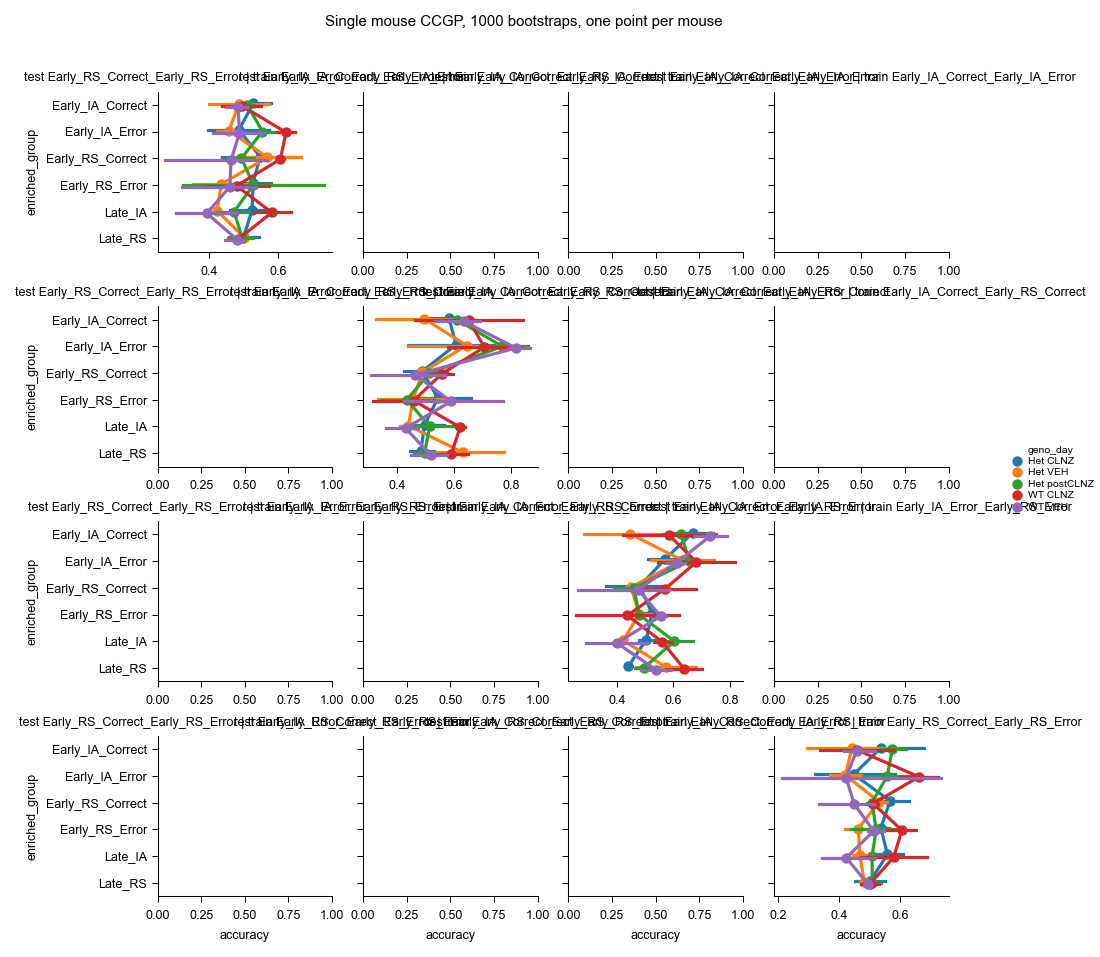

In [97]:
## SINGLE MOUSE CCGP- summary figure
if run_single_mouse_ccgp:
    # average over bootstrap runs within each mouse, then show the spread across mice
    mouse_mean_ccgp = decode_scores_single_mouse.groupby(
        by=['geno_day', 'subject_name', 'enriched_group', 'train_on', 'test_on'])[['accuracy']].mean().reset_index()

    g = sns.catplot(kind='point', data=mouse_mean_ccgp, dodge=True, sharey=True, sharex=False, height=1.6,
                    row='train_on', col='test_on', y='enriched_group', x='accuracy', hue='geno_day')
    g.fig.subplots_adjust(top=0.9)
    g.set_titles("test {col_name} | train {row_name}")
    g.fig.suptitle(f"Single mouse CCGP, {n_single_mouse_runs} bootstraps, one point per mouse")
    display(mouse_mean_ccgp.groupby(['geno_day', 'enriched_group'])['subject_name'].nunique().rename('n_mice'))


## Time-dependent decoding:

#### setup time-dep decoding

In [98]:
def get_start_ends_of_sliced_range(length, chunk_size):
    """ 
    Divides a range of indices into N chunks, ensuring all chunks except the last are the same size.
    Args:
        length (int): The total length of the range.
        chunk_size (int): The size of chunks.
       Returns: np.ndarray: An array of (start, stop) tuples representing the chunk ranges.
    """
    # Compute the size of each chunk
    n_chunks = length // chunk_size
    # Create an array of start indices
    starts = np.arange(0, length, chunk_size)
    # Compute inclusive stop indices so each chunk has exactly chunk_size rows
    stops = starts + chunk_size - 1
    stops[-1] = length - 1
    return np.column_stack((starts, stops))


In [99]:
#function for bootstrapping PCA
def run_SVM_on_timebins_N_bootstrap(store_path_or_dict, class_comparisons, frame_cols, num_resample:int, frame_batch_size, bootstrap_range):
    '''TO- run bootstrap to get cosine sim and sil score of decoded classes for each elem N in bootstrap_range 
    Memory optimizations applied:
    - store_path_or_dict: accepts either a file path (str/Path) for mmap loading, or the dict directly for testing
    - column-wise accumulation instead of list-of-dicts to reduce per-dict overhead
    - float32 cast on resampled matrices to halve intermediate memory
    '''
    if isinstance(store_path_or_dict, dict):
        class_matrix_store = store_path_or_dict
    else:
        import joblib as jl
        class_matrix_store = jl.load(store_path_or_dict, mmap_mode='r')
    
    # column-wise accumulation (lower overhead than list of dicts)
    col_pseudopop_run_num = []
    col_enriched_group = []
    col_class_0 = []
    col_class_1 = []
    col_geno_day = []
    col_frame_subset = []
    col_bin_start_index = []
    col_bin_end_index = []
    col_bin_start_str = []
    col_mean_acc = []
    col_bin_end_str = []
    col_bin_default_size = []
    
    #declare variables for local use
    stage_names = class_matrix_store.keys()
    geno_order = class_matrix_store['Late_IA']['Late_IA'].keys()
    #determine range slice creation
    if frame_batch_size is None: #if default argument, batch size == whole frame cols
        col_ranges = [(0, len(frame_cols))] 
    else:  
        col_ranges = get_start_ends_of_sliced_range(len(frame_cols), frame_batch_size)
        col_ranges= [tuple(row) for row in col_ranges]
    #run main body
    for b in bootstrap_range: #create B class matrix store (where b = number of resamples)
        for stage_enriched_in in stage_names:
            for geno_curr in geno_order:
                ensemble_resample_in_phase_dict = {}
                #if doing time-bin wise resampling, create range of mats to useabs             
                for class_name in stage_names: #store the versions for this bootstrap run
                    ensemble_resample_in_phase_dict[class_name]= dict() #allow for ranges for subsample to be used as keys 
                    for subset in col_ranges: #for each start/end value in ranges, draw a matrix within those frame cols of interest
                        subsample_range = frame_cols[subset[0]:subset[1]]
                        class_matrix = resample_into_class_matrix(class_matrix_store,num_resample,stage_enriched_in, class_name, geno_curr, 
                                                                  subsample_range=subsample_range)
                        ensemble_resample_in_phase_dict[class_name][subset] = class_matrix
    
                for phase_count, phase_pair in enumerate(class_comparisons): #once genotype & enrichment filter, specified, compare phase detection
                    class_0,class_1 = phase_pair[0], phase_pair[1] # print(f"{geno_day_curr}, {e_phase}-enriched units decode: {phase_pair}")
                    subset_info = []
                    
                    for subset in col_ranges: #for each start/end value in ranges, draw a matrix within those frame cols of interest
                        class_mat_0 =ensemble_resample_in_phase_dict[class_0][subset]
                        class_mat_1 =ensemble_resample_in_phase_dict[class_1][subset]
                        concat_matrix,concat_labels =fast_pack_data_local(class_mat_0, class_mat_1,0,1)        #returns concat_matrix, and concat_labels

                        concat_matrix = concat_matrix.values.T #.T.values of concat matrix is to reshape mat into what scikit wants from you
                        cv = model_selection.ShuffleSplit(n_splits = k_folds, test_size =test_size)#Create CV object do leave one out split using minority class indices

                        split_summary = []
                        for split_count, (train, test) in enumerate(cv.split(np.zeros(len(concat_labels)), concat_labels)):
                            model = svm.LinearSVC(C= 1, max_iter=1000, penalty=reg_penalty, dual=False, verbose= 0) #make new model per geno_day classifier split
                            trained_model = model.fit(concat_matrix[train,:], concat_labels[train])                 # score_real = trained_model.score( concat_matrix[test,:], concat_labels[test])#get accuracy
                            precision, recall,score_real = get_test_precision_recall_acc( concat_matrix[test,:], concat_labels[test], trained_model)
                             #get correct bin names
                            if subset[1]==len(frame_cols):
                                bin_end_str = frame_cols[subset[1]-1]
                            else:
                                bin_end_str = frame_cols[subset[1]]   
                            
                            split_summary.append(score_real)
                        #save split info for the given subset
                        #after finishing split run, average then store
                        average_acc = np.mean(split_summary).astype(np.float16)
                        
                        col_pseudopop_run_num.append(b)
                        col_enriched_group.append(stage_enriched_in)
                        col_class_0.append(class_0)
                        col_class_1.append(class_1)
                        col_geno_day.append(geno_curr)
                        col_frame_subset.append(subset)
                        col_bin_start_index.append(subset[0])
                        col_bin_end_index.append(subset[1])
                        col_bin_start_str.append(frame_cols[subset[0]])
                        col_mean_acc.append(average_acc)
                        col_bin_end_str.append(bin_end_str)
                        col_bin_default_size.append(frame_batch_size)
    #once done with all bootstraps, create from column lists
    output_df = pd.DataFrame({
        'pseudopop_run_num': col_pseudopop_run_num,
        'enriched_group': col_enriched_group,
        'class_0': col_class_0,
        'class_1': col_class_1,
        'geno_day': col_geno_day,
        'frame_subset': col_frame_subset,
        'bin_start_index': col_bin_start_index,
        'bin_end_index': col_bin_end_index,
        'bin_start_str': col_bin_start_str,
        'mean_acc': col_mean_acc,
        'bin_end_str': col_bin_end_str,
        'bin_default_size': col_bin_default_size,
    })
    return output_df

In [100]:

frame_batch_size= 8
x = run_SVM_on_timebins_N_bootstrap(class_matrix_store,class_comparisons, numeric_col, 400,12, [1])
x

,pseudopop_run_num,enriched_group,class_0,class_1,geno_day,frame_subset,bin_start_index,bin_end_index,bin_start_str,mean_acc,bin_end_str,bin_default_size
0,1,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(0, 11)",0,11,-3.0s to -2.75s,1.000000,-0.25s to -0.0s,12
1,1,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(12, 23)",12,23,0.0s to 0.25s,1.000000,2.75s to 3.0s,12
2,1,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(24, 35)",24,35,3.0s to 3.25s,0.998535,5.75s to 6.0s,12
3,1,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(36, 47)",36,47,6.0s to 6.25s,0.998535,8.75s to 9.0s,12
4,1,Early_IA_Correct,Early_IA_Correct,Early_IA_Error,Het CLNZ,"(48, 59)",48,59,9.0s to 9.25s,1.000000,11.75s to 12.0s,12
...,...,...,...,...,...,...,...,...,...,...,...,...
1435,1,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"(12, 23)",12,23,0.0s to 0.25s,0.887695,2.75s to 3.0s,12
1436,1,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"(24, 35)",24,35,3.0s to 3.25s,0.939941,5.75s to 6.0s,12
1437,1,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"(36, 47)",36,47,6.0s to 6.25s,0.938965,8.75s to 9.0s,12
1438,1,Late_RS,Late_IA,Early_RS_Correct,WT VEH,"(48, 59)",48,59,9.0s to 9.25s,0.895020,11.75s to 12.0s,12


In [101]:
# set up parallel batch
import tempfile
import joblib as jl

if run_timedep:
    num_resample = 400
    n_jobs = 10
    frame_batch_size= 12
    start_end_iter = make_chunked_iterator_of_ranges(0,n_pseudopop_runs, n_jobs)

    # Memory optimization: dump class_matrix_store to disk so workers can mmap it
    # instead of each worker receiving a pickled copy (~144 MB × 10 workers saved)
    store_path = tempfile.mktemp(suffix='.joblib')
    jl.dump(class_matrix_store, store_path)

    #12 min, 100 runs 
    #36min- 1k runs 
    partial_timebin_svm_func = partial(run_SVM_on_timebins_N_bootstrap, store_path, class_comparisons,
                                    numeric_col, num_resample, frame_batch_size)
    # Collect all parallel results first (weights removed to avoid MemoryError at 10K runs)
    output_SVM_runs = Parallel(n_jobs=n_jobs, verbose=9)(delayed(partial_timebin_svm_func)(x) for x in start_end_iter)

    # Clean up temp file
    os.remove(store_path)
    ## PACKAGE information into function ## versioning info
    timedecode_scores= package_decode_scores_common(output_SVM_runs, hyper_param_dict, trial_df_filename)
    timedecode_scores['classes decoded'] = timedecode_scores.class_0.str.cat(timedecode_scores.class_1, sep = '_v_')#.astype('category')
    timedecode_scores.head()

In [102]:
if run_timedep:
    timedecode_scores = timedecode_scores.rename({'class_0': 'Phase1', 'class_1':'Phase2'}, axis = 1)
    timedecode_scores['timebin_size'] = hyper_param_dict['bin_size']
    timedecode_scores['run_end_time'] = datetime.now()
    timedecode_scores['dataset_folder_name'] = str(trial_df_filename)
    timedecode_scores.bin_start_str = timedecode_scores.bin_start_str.str.split(' to ').str[0]
    timedecode_scores.bin_end_str = timedecode_scores.bin_end_str.str.split(' to ').str[1]
    timedecode_scores['bin_name'] = timedecode_scores.bin_start_str.str.cat( timedecode_scores.bin_end_str, sep = ' to ')
    timedecode_scores['frame_subset'] = timedecode_scores['frame_subset']#.astype('category')
    timedecode_scores.loc[:,['enriched_group', 'Phase1','Phase2', 'geno_day']] = timedecode_scores.loc[:,['enriched_group', 'Phase1','Phase2', 'geno_day']]#.astype('category')
    timedecode_scores.info()

    ## save output file:
    timedecode_file_name = output_folder / Path( f"Timebin {frame_batch_size}_window Decoding- {n_pseudopop_runs}_bootstrap {data_type} {date_tag}.parquet")
    timedecode_scores.to_parquet(timedecode_file_name, compression='snappy')
    print(f"decoding file name: {timedecode_file_name}")
    # timedecode_scores.to_csv(decode_csv_name)
    print(timedecode_scores.info())
    timedecode_scores
    
    ## save metatdata of current run
    f = open("last_time_decoding_run_info.txt", "w")
    decode_run_info_str = f"latest time-based decoding output filename: {timedecode_file_name}. Run end: {date_tag}. Data used: {str(trial_df_filename)}"
    f.write(decode_run_info_str)
    f.close()
    print(decode_run_info_str)

In [103]:
# Weight saving removed for timebin decoding to avoid MemoryError at 10K pseudopop runs
# (weight accumulation was the source of ~5.5 GB per worker that couldn't serialize back)

In [104]:
# weights_timedep_filename  # removed with weight saving

## save summaries of decoding performance

In [105]:
# Define mapping of decoding types to their output file variables
# Each entry: (decoding_type_name, output_file_variable_name)
decoding_types_config = [
    ('in_distribution', 'decode_file_name'),
    ('out_of_distribution', 'decode_file_name_out_distrib'),
    ('out_of_distribution_whole_pop', 'decode_file_name_whole_pop'),
    ('out_of_distribution_label_permuted', 'decode_file_name_label_permuted'),
    ('out_of_distribution_whole_pop_permuted', 'decode_file_whole_pop_label_permuted'),
    ('out_of_distribution_activity_match', 'decode_CCG_activity_match'),
    ('single_mouse_out_of_distribution', 'decode_file_name_single_mouse'),
    ('timebin_decoding', 'timedecode_file_name'),
]

weight_filenames = {
    'in_distribution': weights_in_distrib_filename if run_binary_SVM else None,
    'out_of_distribution': weights_out_distrib_filename if run_CCGP_base else None,
    'out_of_distribution_whole_pop': weights_whole_pop_filename if  run_allcell_ccgp else None,
    'out_of_distribution_label_permuted': weights_label_permuted_filename if run_CCGP_permuted else None,
}
# Create run info dataframes for all performed decoding types
run_info_dfs = []
for decoding_type, file_var_name in decoding_types_config:
    # Check if the output file variable exists (i.e., that decoding was performed)
    if file_var_name in dir():
        output_file = eval(file_var_name)
        run_info = {
            'run_date': date_tag, 
            'decoding_type': decoding_type, 
            'data_type': data_type,
            'run_end_time': datetime.now(),
            'run_dataset_used': str(trial_df_filename),
            'run_output_filename': output_file, 
            'n_jobs': n_jobs,
            'n_iterations': n_pseudopop_runs, 
            'activity_file': cell_activity_file_name if ('out_of_distribution' in decoding_type) and run_activity_save else 'N/A',
            'weight_file_saved': weight_filenames.get(decoding_type, 'N/A')
        }
        run_info_dfs.append(pd.DataFrame([run_info]))
        print(f"Created run info for: {decoding_type}")
    else:
        print(f"Skipped {decoding_type} - {file_var_name} not found (decoding not performed)")

# Concatenate all run info dataframes
current_runs_info = pd.concat(run_info_dfs, ignore_index=True)
current_runs_info

Skipped in_distribution - decode_file_name not found (decoding not performed)
Skipped out_of_distribution - decode_file_name_out_distrib not found (decoding not performed)
Skipped out_of_distribution_whole_pop - decode_file_name_whole_pop not found (decoding not performed)
Skipped out_of_distribution_label_permuted - decode_file_name_label_permuted not found (decoding not performed)
Skipped out_of_distribution_whole_pop_permuted - decode_file_whole_pop_label_permuted not found (decoding not performed)
Skipped out_of_distribution_activity_match - decode_CCG_activity_match not found (decoding not performed)
Created run info for: single_mouse_out_of_distribution
Skipped timebin_decoding - timedecode_file_name not found (decoding not performed)


,run_date,decoding_type,data_type,run_end_time,run_dataset_used,run_output_filename,n_jobs,n_iterations,activity_file,weight_file_saved
0,20_Aug_2026,single_mouse_out_of_distribution,post_outcome_activity,2026-08-20 15:08:42.075823,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,N/A,N/A


In [106]:
os.getcwd()

'C:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\results\\figure_5_prep_mid_decoding figures_post_outcome_activity_20_Aug_2026'

In [107]:

generalize_svm_record_file = f"Decoder- Out of Distribution - run version record.csv"
svm_file_loc = data_dir
if not os.path.exists(generalize_svm_record_file):    #create locally then save
    run_record_generalize = current_runs_info
else: #load and add to it 
    run_record_generalize= pd.read_csv(generalize_svm_record_file)
    run_record_generalize = pd.concat([run_record_generalize, current_runs_info]).reset_index(drop=True)
    run_record_generalize = run_record_generalize.drop([c for c in run_record_generalize.columns if 'Unnamed' in c],axis = 1)
#if CSV doesn't exist, create
run_record_generalize.to_csv(generalize_svm_record_file)
run_record_generalize

,run_date,decoding_type,data_type,run_end_time,run_dataset_used,run_output_filename,n_jobs,n_iterations,activity_file,weight_file_saved
0,20_Aug_2026,single_mouse_out_of_distribution,post_outcome_activity,2026-08-20 15:08:42.075823,c:\Users\13car\Dropbox\local_github_repos_pers...,C:\Users\13car\Dropbox\local_github_repos_pers...,10,1000,N/A,N/A


In [108]:
print(os.getcwd())
print(f"used {run_record_generalize.run_dataset_used.unique()} dataset for current runs")

C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_post_outcome_activity_20_Aug_2026
used ['c:\\Users\\13car\\Dropbox\\local_github_repos_personal\\dlx56_mPFC_1p_SohalLab\\data\\matlab-made_trial_timeseries_normalized_2026-01-31 17.parquet'] dataset for current runs


In [109]:
#all decoding names: 
# decoding file name: C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\figure_5_prep_mid_decoding figures_16_Jan_2026\Timebin Decoding- 10000_bootstrap post_outcome_activity 16_Jan_2026.parquet
